### Exploratory Data Analysis

Input: `data/interim/movie_train_eda.csv` - tập train sau khi drop missing financials, tạo biến mục tiêu và split, trước engineer features, encode và scale.

`data/interim/df_kept_financials.csv` - toàn bộ dữ liệu giữ lại sau drop missing financials (budget hoặc revenue)

`data/interim/df_dropped_financials.csv` - dữ liệu thiếu financials

Mục tiêu:
1. Đánh giá selection bias (kept vs dropped financials)
2. Univariate analysis
3. Bivariate: profitable vs một số feature
4. Multivariate: correlation

In [74]:
import pandas as pd
import numpy as np
import ast
import os
import warnings

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import scipy.stats as stats

warnings.filterwarnings('ignore')

CURRENT_DIR = os.getcwd()
DATA_PATH = os.path.join(CURRENT_DIR, '..', 'data')
INTERIM_DATA_PATH = os.path.join(DATA_PATH, 'interim')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 13, 'axes.labelsize': 11})
PALETTE = {'0': '#E07B54', '1': '#5B8DB8'}
C0, C1 = PALETTE['0'], PALETTE['1']

TMDB_GENRES = {
    28: "Action", 12: "Adventure", 16: "Animation", 35: "Comedy", 80: "Crime",
    99: "Documentary", 18: "Drama", 10751: "Family", 14: "Fantasy", 36: "History",
    27: "Horror", 10402: "Music", 9648: "Mystery", 10749: "Romance",
    878: "Sci-Fi", 10770: "TV Movie", 53: "Thriller", 10752: "War", 37: "Western"
}

N_LANG = 10
N_COUNTRY = 10

In [75]:
df = pd.read_csv(os.path.join(INTERIM_DATA_PATH, 'movie_train_eda.csv'))
df_kept    = pd.read_csv(os.path.join(INTERIM_DATA_PATH, 'df_kept_financials.csv'))
df_dropped = pd.read_csv(os.path.join(INTERIM_DATA_PATH, 'df_dropped_financials.csv'))

def parse_list(x):
    try: return ast.literal_eval(x)
    except: return []

for col in ['genres', 'production_companies', 'keywords', 'origin_country', 'top_3_cast', 'director']:
    if col in df.columns:
        df[col] = df[col].apply(parse_list)

df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year']  = df['release_date'].dt.year
df['release_month'] = df['release_date'].dt.month

df['genres_named'] = df['genres'].apply(
    lambda lst: [TMDB_GENRES.get(g, str(g)) for g in lst]
)

df_kept['release_year']    = pd.to_datetime(df_kept['release_date'],    errors='coerce').dt.year
df_dropped['release_year'] = pd.to_datetime(df_dropped['release_date'], errors='coerce').dt.year
df_kept['genres_parsed']    = df_kept['genres'].apply(parse_list)
df_dropped['genres_parsed'] = df_dropped['genres'].apply(parse_list)

df['n_genres']   = df['genres'].apply(len)
df['n_pc']       = df['production_companies'].apply(len)
df['n_keywords'] = df['keywords'].apply(len)

print(f"Train EDA: {df.shape[0]:,} phim - {df.shape[1]} cột")
print(f"Kept     : {df_kept.shape[0]:,} phim")
print(f"Dropped  : {df_dropped.shape[0]:,} phim")
print(f"Drop rate: {df_dropped.shape[0]/(df_kept.shape[0]+df_dropped.shape[0])*100:.1f}%")

Train EDA: 1,780 phim - 20 cột
Kept     : 2,226 phim
Dropped  : 3,956 phim
Drop rate: 64.0%


#### Selection Bias

Khi drop 3,956 phim không có budget hoặc revenue, cần kiểm tra xem tập dữ liệu còn lại liệu có bị lệch về một phân khúc phim nhất định không. Nếu bias có hệ thống, các kết luận từ EDA và mô hình chỉ đại diện cho một tập con chứ không phải toàn bộ thị trường.

**runtimeMinutes**

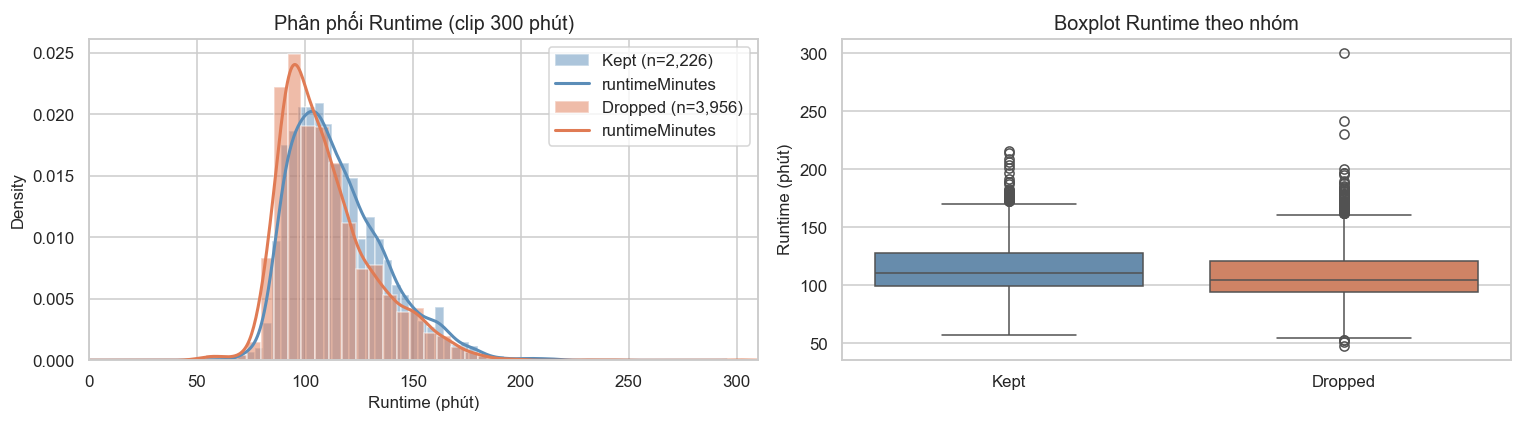

Median:
Kept: 111 phút | Dropped: 105 phút


In [76]:
runtime_kept    = df_kept['runtimeMinutes'].dropna()
runtime_dropped = df_dropped['runtimeMinutes'].dropna()
limit_val = 300

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for label, data, color in [('Kept', runtime_kept, C1), ('Dropped', runtime_dropped, C0)]:
    clipped = data.clip(upper=limit_val)
    axes[0].hist(clipped, bins=40, alpha=0.5, color=color,
                 label=f"{label} (n={len(data):,})", density=True)
    clipped.plot.kde(ax=axes[0], color=color, lw=2)
axes[0].set_xlim(0, limit_val + 10)
axes[0].set_title(f'Phân phối Runtime (clip {limit_val} phút)')
axes[0].set_xlabel('Runtime (phút)')
axes[0].legend()

df_bias_rt = pd.concat([
    runtime_kept.clip(upper=limit_val).rename('runtime').to_frame().assign(_group='Kept'),
    runtime_dropped.clip(upper=limit_val).rename('runtime').to_frame().assign(_group='Dropped')
])
sns.boxplot(data=df_bias_rt, x='_group', y='runtime', ax=axes[1],
            palette={'Kept': C1, 'Dropped': C0})
axes[1].set_title('Boxplot Runtime theo nhóm')
axes[1].set_xlabel('')
axes[1].set_ylabel('Runtime (phút)')

plt.tight_layout()
plt.show()

print(f"Median:\nKept: {runtime_kept.median():.0f} phút | Dropped: {runtime_dropped.median():.0f} phút")

- Xu hướng phân phối: Cả hai nhóm đều có phân phối lệch phải, tập trung chủ yếu trong khoảng 90–120 phút.
- So sánh trung vị: Nhóm kept ghi nhận trung vị cao hơn một chút so với nhóm dropped. 

Quan sát cho thấy có thể tồn tại Selection Bias nhẹ với cột runtime. Nhóm thiếu dữ liệu tài chính (dropped) có xu hướng tập trung vào các bộ phim với thời lượng ngắn hơn. Tuy nhiên hiện tượng này nằm trong phạm vi chấp nhận được.

**release_year**

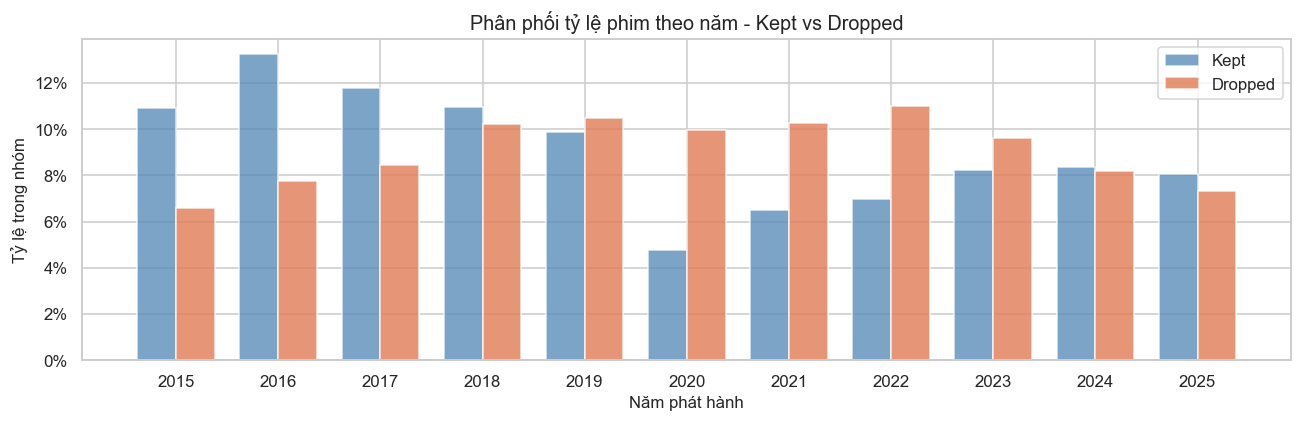

In [77]:
year_kept    = df_kept['release_year'].value_counts(normalize=True).sort_index()
year_dropped = df_dropped['release_year'].value_counts(normalize=True).sort_index()

year_df = pd.DataFrame({'Kept': year_kept, 'Dropped': year_dropped}).fillna(0)
year_df = year_df[(year_df.index >= 2015) & (year_df.index <= 2025)]

fig, ax = plt.subplots(figsize=(12, 4))
x     = np.arange(len(year_df))
width = 0.38
ax.bar(x - width/2, year_df['Kept'],    width, label='Kept',    color=C1, alpha=0.8)
ax.bar(x + width/2, year_df['Dropped'], width, label='Dropped', color=C0, alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(year_df.index.astype(int))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.set_title('Phân phối tỷ lệ phim theo năm - Kept vs Dropped')
ax.set_xlabel('Năm phát hành')
ax.set_ylabel('Tỷ lệ trong nhóm')
ax.legend()
plt.tight_layout()
plt.show()

Giai đoạn 2015-2018: Nhóm kept chiếm ưu thế về tỷ trọng so với nhóm dropped, cho thấy phim phát hành trước COVID có dữ liệu tài chính rạp hoàn chỉnh hơn. Giai đoạn 2019-2022: Kept giảm mạnh, trùng với thời điểm COVID làm gián đoạn phát hành rạp.

**original_language**

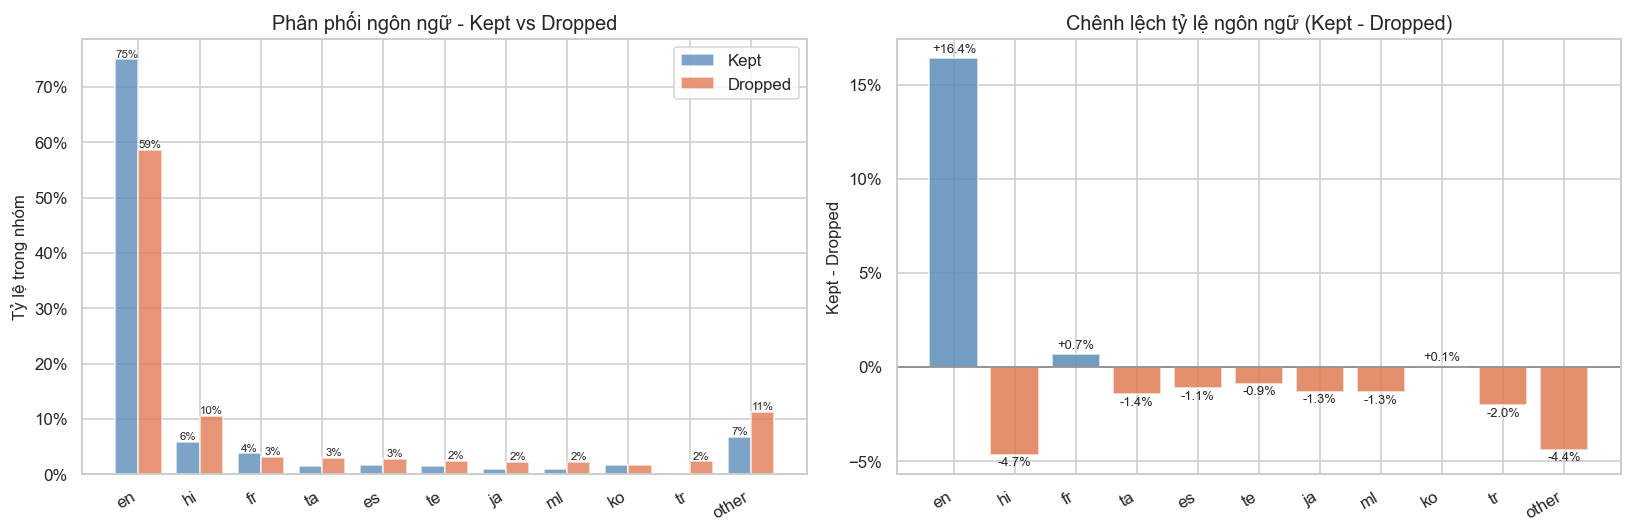

[[1669  130   84   33   36   34   22   21   38    7  152]
 [2317  415  122  115  109   95   91   90   65   93  444]]
Chi-square test (ngôn ngữ): chi2=214.2, p=0.000000
→ Phân phối ngôn ngữ KHÁC BIỆT có ý nghĩa thống kê


In [78]:
TOP_LANGS = (
    pd.concat([df_kept['original_language'], df_dropped['original_language']])
    .value_counts().head(N_LANG).index.tolist()
)

def lang_counts_vec(sub, top_langs):
    grp = sub['original_language'].where(sub['original_language'].isin(top_langs), 'other')
    vc  = grp.value_counts(normalize=True)
    return [vc.get(l, 0) for l in top_langs + ['other']]

order  = TOP_LANGS + ['other']
lang_df = pd.DataFrame({
    'Kept':    lang_counts_vec(df_kept,    TOP_LANGS),
    'Dropped': lang_counts_vec(df_dropped, TOP_LANGS)
}, index=order)
lang_df['diff'] = lang_df['Kept'] - lang_df['Dropped']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
x = np.arange(len(order)); width = 0.38
axes[0].bar(x - width/2, lang_df['Kept'],    width, label='Kept',    color=C1, alpha=0.8)
axes[0].bar(x + width/2, lang_df['Dropped'], width, label='Dropped', color=C0, alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(order, rotation=30, ha='right')
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
axes[0].set_title('Phân phối ngôn ngữ - Kept vs Dropped')
axes[0].set_ylabel('Tỷ lệ trong nhóm')
axes[0].legend()
for i in range(len(order)):
    for val, offset in [(lang_df['Kept'].iloc[i], -width/2), (lang_df['Dropped'].iloc[i], width/2)]:
        if val > 0.02:
            axes[0].text(i + offset, val + 0.004, f'{val:.0%}', ha='center', fontsize=7.5)

colors_diff = [C1 if d > 0 else C0 for d in lang_df['diff']]
axes[1].bar(order, lang_df['diff'], color=colors_diff, alpha=0.85, edgecolor='white')
axes[1].axhline(0, color='gray', lw=1)
axes[1].set_xticklabels(order, rotation=30, ha='right')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
axes[1].set_title('Chênh lệch tỷ lệ ngôn ngữ (Kept - Dropped)')
axes[1].set_ylabel('Kept - Dropped')
for i, (lang, row) in enumerate(lang_df.iterrows()):
    axes[1].text(i, row['diff'] + (0.003 if row['diff'] >= 0 else -0.006),
                f'{row["diff"]:+.1%}', ha='center', fontsize=8.5)

plt.tight_layout()
plt.show()

# Chi-square
def lang_count_abs(sub, top_langs):
    grp = sub['original_language'].where(sub['original_language'].isin(top_langs), 'other')
    vc  = grp.value_counts()
    return [vc.get(l, 0) for l in top_langs + ['other']]

contingency = np.array([lang_count_abs(df_kept, TOP_LANGS), lang_count_abs(df_dropped, TOP_LANGS)])
print(contingency)
chi2, p, dof, _ = stats.chi2_contingency(contingency)
print(f"Chi-square test (ngôn ngữ): chi2={chi2:.1f}, p={p:.6f}")
print("→", "Phân phối ngôn ngữ KHÁC BIỆT có ý nghĩa thống kê" if p < 0.05 else "Không có sự khác biệt")

Nhóm kept tập trung chủ yếu vào phim tiếng Anh (~75%), trong khi đối với nhóm thiếu dữ liệu tài chính, phim tiếng Anh chỉ chiếm ~59%. Phim tiếng Ấn Độ (hi) và một số ngôn ngữ châu Á chiếm tỷ trọng cao hơn trong dropped - các thị trường này có dữ liệu tài chính rạp được TMDB ghi nhận kém hoàn chỉnh hơn.

Kết quả kiểm định cho thấy việc thiếu dữ liệu tài chính không xảy ra ngẫu nhiên mà có liên quan đến ngôn ngữ của phim. Hiện tượng này có thể khiến mô hình có biên độ sai số cao hơn khi áp dụng cho các phim không phải tiếng Anh.

**genres**

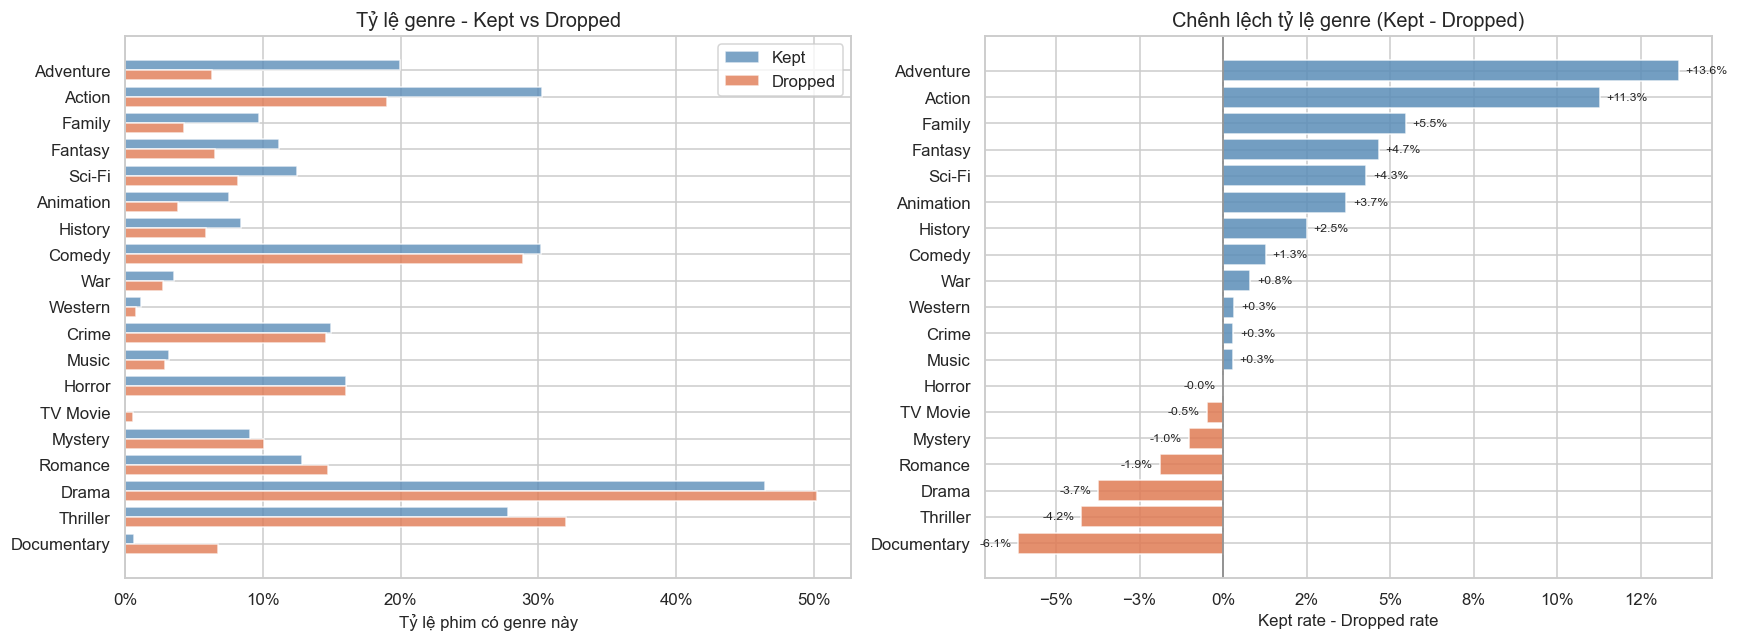

[[ 674  444  167  672  332   14 1035  216  249  187  357   71  201  286
   277    1  618   79   25]
 [ 752  250  151 1144  578  267 1987  168  258  233  635  115  398  583
   323   21 1266  108   31]]
Chi-square test (genre distribution): chi2=574.5, p=0.000000
→ Phân phối genre KHÁC BIỆT có ý nghĩa thống kê


In [79]:
genre_rows = []
for gid, gname in TMDB_GENRES.items():
    k_rate = df_kept['genres_parsed'].apply(lambda g: gid in g).mean()
    d_rate = df_dropped['genres_parsed'].apply(lambda g: gid in g).mean()
    genre_rows.append({'genre': gname, 'kept': k_rate, 'dropped': d_rate, 'diff': k_rate - d_rate})

genre_bias_df = pd.DataFrame(genre_rows).sort_values('diff', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

x = np.arange(len(genre_bias_df)); width = 0.38
axes[0].barh(x + width/2, genre_bias_df['kept'],    width, label='Kept',    color=C1, alpha=0.8)
axes[0].barh(x - width/2, genre_bias_df['dropped'], width, label='Dropped', color=C0, alpha=0.8)
axes[0].set_yticks(x)
axes[0].set_yticklabels(genre_bias_df['genre'])
axes[0].set_xlabel('Tỷ lệ phim có genre này')
axes[0].set_title('Tỷ lệ genre - Kept vs Dropped')
axes[0].legend()
axes[0].xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))

colors_diff = [C1 if d > 0 else C0 for d in genre_bias_df['diff']]
axes[1].barh(genre_bias_df['genre'], genre_bias_df['diff'],
             color=colors_diff, alpha=0.85, edgecolor='white')
axes[1].axvline(0, color='gray', lw=1)
axes[1].set_xlabel('Kept rate - Dropped rate')
axes[1].set_title('Chênh lệch tỷ lệ genre (Kept - Dropped)')
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
for i, (_, row) in enumerate(genre_bias_df.iterrows()):
    axes[1].text(row['diff'] + (0.002 if row['diff'] >= 0 else -0.002), i,
                 f"{row['diff']:+.1%}",
                 va='center', ha='left' if row['diff'] >= 0 else 'right', fontsize=8)

plt.tight_layout()
plt.show()

# Chi-square
all_genre_ids      = list(TMDB_GENRES.keys())
kept_genre_flat    = df_kept['genres_parsed'].explode().dropna()
dropped_genre_flat = df_dropped['genres_parsed'].explode().dropna()
contingency_genres = np.array([
    [kept_genre_flat.value_counts().get(gid, 0)    for gid in all_genre_ids],
    [dropped_genre_flat.value_counts().get(gid, 0) for gid in all_genre_ids]
])
print(contingency_genres)
chi2, p, dof, _ = stats.chi2_contingency(contingency_genres)
print(f"Chi-square test (genre distribution): chi2={chi2:.1f}, p={p:.6f}")
print("→", "Phân phối genre KHÁC BIỆT có ý nghĩa thống kê" if p < 0.05 else "Không có sự khác biệt")

Các thể loại như Adventure (+13.6%), Action (+11.3%), và Family (+5.5%) xuất hiện nhiều hơn hẳn trong nhóm kept - đây là các genre gắn với phim rạp lớn có dữ liệu tài chính được ghi nhận đầy đủ. Ngược lại, Documentary (-6.1%) và Thriller (-4.2%) chiếm tỷ trọng cao hơn trong dropped, đặc biệt tỷ lệ thiếu dữ liệu tài chính ở phim tài liệu khá cao.

Kết quả kiểm định cho thấy việc thiếu dữ liệu tài chính có sự ảnh hưởng của thể loại. Đối với các dòng phim đặc thù như Documentary, mô hình có thể gặp khó khăn do dữ liệu thiếu hụt.

**certification_us**

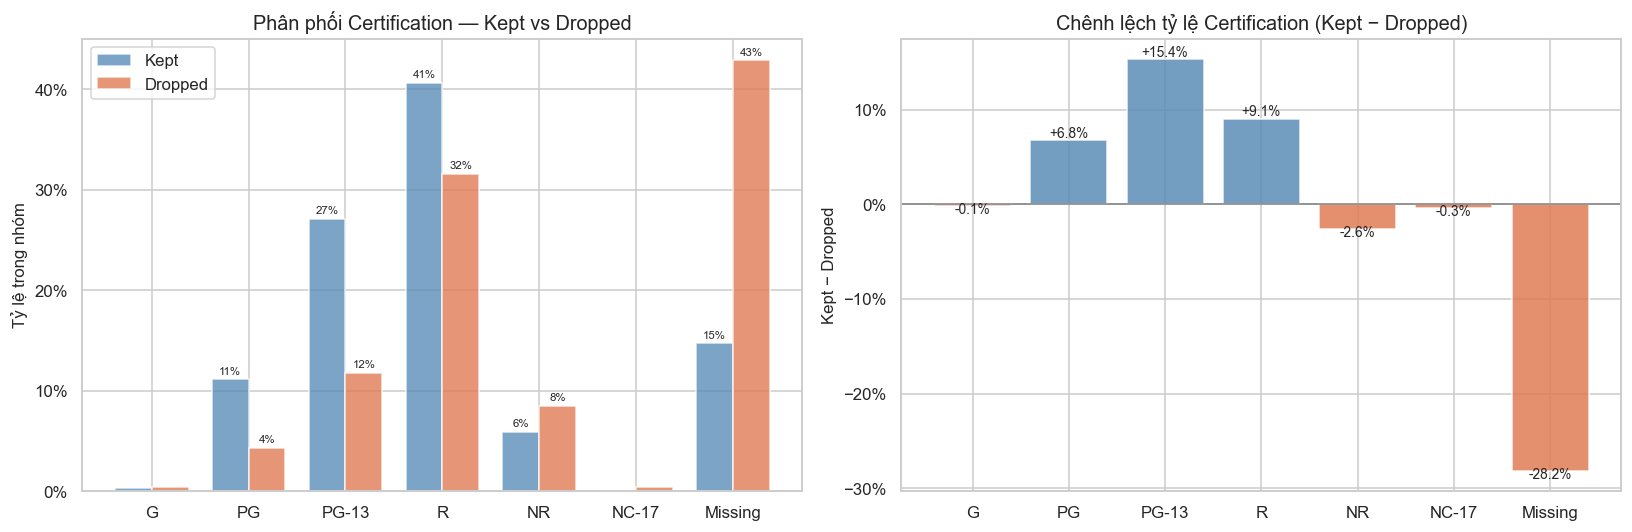

In [80]:
CERT_ORDER = ['G', 'PG', 'PG-13', 'R', 'NR', 'NC-17', 'Missing']

def cert_rate_vec(series, order):
    vc = series.fillna('Missing').value_counts(normalize=True)
    return [vc.get(c, 0) for c in order]

def cert_count_vec(series, order):
    vc = series.fillna('Missing').value_counts()
    return [vc.get(c, 0) for c in order]

cert_df = pd.DataFrame({
    'Kept':    cert_rate_vec(df_kept['certification_us'],    CERT_ORDER),
    'Dropped': cert_rate_vec(df_dropped['certification_us'], CERT_ORDER)
}, index=CERT_ORDER)
cert_df['diff'] = cert_df['Kept'] - cert_df['Dropped']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
x = np.arange(len(CERT_ORDER)); width = 0.38
axes[0].bar(x - width/2, cert_df['Kept'],    width, label='Kept',    color=C1, alpha=0.8)
axes[0].bar(x + width/2, cert_df['Dropped'], width, label='Dropped', color=C0, alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(CERT_ORDER)
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
axes[0].set_title('Phân phối Certification — Kept vs Dropped')
axes[0].set_ylabel('Tỷ lệ trong nhóm')
axes[0].legend()
for i in range(len(CERT_ORDER)):
    for val, offset in [(cert_df['Kept'].iloc[i], -width/2), (cert_df['Dropped'].iloc[i], width/2)]:
        if val > 0.01:
            axes[0].text(i + offset, val + 0.005, f'{val:.0%}', ha='center', fontsize=7.5)

colors_diff = [C1 if d > 0 else C0 for d in cert_df['diff']]
axes[1].bar(CERT_ORDER, cert_df['diff'], color=colors_diff, alpha=0.85, edgecolor='white')
axes[1].axhline(0, color='gray', lw=1)
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
axes[1].set_title('Chênh lệch tỷ lệ Certification (Kept − Dropped)')
axes[1].set_ylabel('Kept − Dropped')
for i, (idx, row) in enumerate(cert_df.iterrows()):
    axes[1].text(i, row['diff'] + (0.003 if row['diff'] >= 0 else -0.008),
                f'{row["diff"]:+.1%}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

Nhóm dropped có tới 43% phim không có chứng nhận MPAA, trong khi con số này ở nhóm kept chỉ là 15%. Có thể thấy phim thiếu dữ liệu tài chính phần lớn cũng thiếu nhãn MPAA, với hơn 50% trong nhóm dropped là NR hoặc missing. 

Từ quan sát, ta có thể cho rằng việc thiếu dữ liệu tài chính và việc thiếu chứng nhận MPAA có mối liên hệ với nhau.

**Kết luận selection bias:** 

Tập dữ liệu giữ lại có thể nghiêng về phim có ngân sách trung bình-lớn, phát hành rộng rãi, chủ yếu Anh ngữ. Kết quả mô hình cần được diễn giải trong bối cảnh này.

##### Phân tích vùng nhiễu nhãn quanh ngưỡng 2.5x

Tổng phim có dữ liệu tài chính: 2,226
Phim trong vùng [2.3x, 2.7x]: 122 (5.5%)
Phim ngoài vùng nhiễu: 2,104 (94.5%)


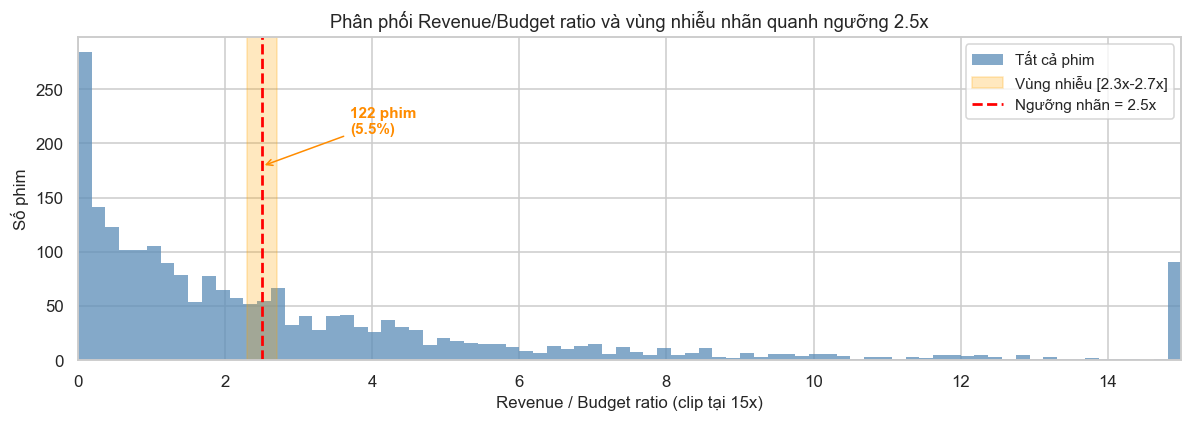

In [81]:
RATIO_LOW  = 2.3
RATIO_HIGH = 2.7
THRESHOLD  = 2.5

# Tính ratio cho toàn bộ tập (chỉ những phim có budget > 0)
df_ratio = df_kept[(df_kept['budget'] > 0) & (df_kept['revenue'] > 0)].copy()
df_ratio['revenue_budget_ratio'] = df_ratio['revenue'] / df_ratio['budget']

total = len(df_ratio)
ambiguous = df_ratio[
    (df_ratio['revenue_budget_ratio'] >= RATIO_LOW) &
    (df_ratio['revenue_budget_ratio'] <= RATIO_HIGH)
]
n_ambiguous = len(ambiguous)
pct_ambiguous = n_ambiguous / total * 100

print(f"Tổng phim có dữ liệu tài chính: {total:,}")
print(f"Phim trong vùng [{RATIO_LOW}x, {RATIO_HIGH}x]: {n_ambiguous:,} ({pct_ambiguous:.1f}%)")
print(f"Phim ngoài vùng nhiễu: {total - n_ambiguous:,} ({100 - pct_ambiguous:.1f}%)")

CLIP_MAX = 15
ratio_clipped = df_ratio['revenue_budget_ratio'].clip(upper=CLIP_MAX)

fig, ax = plt.subplots(figsize=(11, 4))

ax.hist(ratio_clipped, bins=80, color='#5B8DB8', alpha=0.75, edgecolor='none', label='Tất cả phim')
ax.axvspan(RATIO_LOW, RATIO_HIGH, alpha=0.25, color='orange', label=f'Vùng nhiễu [{RATIO_LOW}x-{RATIO_HIGH}x]')
ax.axvline(THRESHOLD, color='red', linewidth=1.8, linestyle='--', label=f'Ngưỡng nhãn = {THRESHOLD}x')

ax.set_xlabel(f'Revenue / Budget ratio (clip tại {CLIP_MAX}x)', fontsize=11)
ax.set_ylabel('Số phim', fontsize=11)
ax.set_title('Phân phối Revenue/Budget ratio và vùng nhiễu nhãn quanh ngưỡng 2.5x', fontsize=12)
ax.legend(fontsize=10)
ax.set_xlim(0, CLIP_MAX)

ax.annotate(
    f'{n_ambiguous} phim\n({pct_ambiguous:.1f}%)',
    xy=(THRESHOLD, ax.get_ylim()[1] * 0.6),
    xytext=(THRESHOLD + 1.2, ax.get_ylim()[1] * 0.7),
    arrowprops=dict(arrowstyle='->', color='darkorange'),
    color='darkorange', fontsize=10, fontweight='bold'
)

plt.tight_layout()
plt.show()

Phim có tỷ lệ giữa revenue/budget nằm trong vùng nhiễu [2.3x, 2.7x] chiếm 5.5% tổng tập dữ liệu. Tác động lên chất lượng nhãn không quá lớn.

##### Kiểm tra chất lượng dữ liệu và quyết định xử lý (thực hiện trên train sau khi split)

In [82]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1780 entries, 0 to 1779
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   tconst                1780 non-null   str           
 1   startYear             1780 non-null   int64         
 2   runtimeMinutes        1780 non-null   float64       
 3   budget                1780 non-null   float64       
 4   production_companies  1780 non-null   object        
 5   original_language     1780 non-null   str           
 6   origin_country        1780 non-null   object        
 7   top_3_cast            1780 non-null   object        
 8   director              1780 non-null   object        
 9   keywords              1780 non-null   object        
 10  genres                1780 non-null   object        
 11  certification_us      1522 non-null   str           
 12  release_date          1780 non-null   datetime64[us]
 13  profitable            1780 no

In [83]:
# top_3_cast & director: temporal leakage + inconsistency

def analyze_inconsistency(df, column_name):
    all_pairs = []
    valid_data = df[column_name].dropna()
    for row in valid_data:
        for item in row:
            if isinstance(item, dict) and 'id' in item and 'popularity' in item:
                all_pairs.append({'id': item['id'], 'popularity': item['popularity']})
    if not all_pairs:
        return pd.DataFrame()
    temp_df = pd.DataFrame(all_pairs)
    report = temp_df.groupby('id')['popularity'].unique().reset_index()
    report['unique_count'] = report['popularity'].apply(len)
    inconsistent = report[report['unique_count'] > 1].copy()
    inconsistent['diff'] = inconsistent['popularity'].apply(lambda x: max(x) - min(x))
    return inconsistent.sort_values('diff', ascending=False)

for col in ['top_3_cast', 'director']:
    result = analyze_inconsistency(df, col)
    print(col.upper())
    if result.empty:
        print("- Không có sự thiếu nhất quán.")
    else:
        print(f"- Phát hiện {len(result)} entity có điểm thay đổi.")
        print(result[['id', 'unique_count', 'diff']].head())

TOP_3_CAST
- Phát hiện 349 entity có điểm thay đổi.
        id  unique_count    diff
96    1204             2  2.0071
234   3967             2  1.9826
191   2963             2  1.7911
406  10431             2  1.6619
36     287             2  1.4765
DIRECTOR
- Phát hiện 106 entity có điểm thay đổi.
         id  unique_count    diff
356   54507             2  0.9225
666  124747             2  0.8554
568   87877             2  0.6968
147   11090             2  0.6086
79     4014             2  0.5917


*Vấn đề với cast_popularity và director_popularity*

Sau khi xem xét lại 2 biến này, nhóm nhận định tồn tại các vấn đề

- Temporal leakage: TMDB popularity là điểm real-time tại thời điểm gọi API, không phải tại thời điểm phim ra mắt. Một diễn viên nổi tiếng năm 2024 vì một bộ phim mới sẽ có điểm cao cho tất cả phim cũ của họ - kể cả phim từ năm 2005. Mô hình sẽ học được thông tin từ tương lai, dẫn đến sai lệch so với thực tế.

- Data inconsistency: Cùng một id cho ra điểm popularity khác nhau ở các dòng dữ liệu khác nhau trong cùng một lần query API. Nguyên nhân có thể do dữ liệu từ TMDB không đồng nhất giữa các phim. Sự không nhất quán này cho thấy dữ liệu không ổn định, không đảm bảo độ tin cậy và chất lượng.

Từ các lý do trên, nhóm quyết định drop 2 cột này để tránh đưa nhiễu vào mô hình.

In [84]:
# startYear vs release_date: kiểm tra lệch năm

df['release_year'] = df['release_date'].dt.year
df['startYear'] = pd.to_numeric(df['startYear'], errors='coerce')

inconsistent_df = df[df['release_year'] != df['startYear']].copy()
inconsistent_df['year_diff'] = inconsistent_df['release_year'] - inconsistent_df['startYear']

print(f"Phim bị lệch năm: {len(inconsistent_df)} / {len(df)}")
print("\nThống kê khoảng cách lệch:")
print(inconsistent_df['year_diff'].value_counts().sort_index())
print(inconsistent_df[['tconst','startYear','release_date','release_year','year_diff']].to_string(index=False))

Phim bị lệch năm: 98 / 1780

Thống kê khoảng cách lệch:
year_diff
1    91
2     6
5     1
Name: count, dtype: int64
    tconst  startYear release_date  release_year  year_diff
tt22375054       2023   2024-08-14          2024          1
 tt8503618       2020   2025-09-05          2025          5
tt33028778       2025   2026-01-01          2026          1
 tt5270948       2017   2018-04-06          2018          1
 tt5883570       2017   2018-11-02          2018          1
 tt3859304       2015   2016-01-22          2016          1
 tt4573516       2016   2017-04-28          2017          1
 tt4857264       2016   2017-01-06          2017          1
tt14966898       2023   2024-03-19          2024          1
 tt3833480       2019   2020-06-24          2020          1
 tt1667321       2017   2018-01-19          2018          1
 tt5461944       2018   2019-03-14          2019          1
tt11317142       2020   2021-03-26          2021          1
 tt9731534       2020   2021-07-15          

Nhóm phim lệch 1-2 năm: Kiểm tra nhận thấy chủ yếu do imdb lấy release date film festival, thực tế sau đó 1 khoảng thời gian mới chính thức ra rạp

1 phim lệch 5: tt8503618 2020 2025-09-05: Kiểm tra nhận thấy phim này ra mắt trên internet từ 2020, đến 2025 mới ra rạp

Nhận thấy rằng trường startYear từ imdb có nguy cơ sai lệch do ngày ra mắt không phải chính thức. Do đó, nhóm quyết định drop cột startYear, thay thế bằng cột release_year sẽ trích xuất từ release_date

Trong bước xử lý sẽ thực hiện kiểm tra các giá trị release date nằm ngoài scope 2015-2025 (nghi vấn sẽ có một số phim 2026 do imdb lấy ngày ra mắt của film fes như trên), và drop

##### MISSING VALUE

In [85]:
print("\n--- Missing Values (Train) ---")
def count_true_missing(series):
    # Đếm NaN thông thường
    if series.dtype != 'object':
        return series.isnull().sum()
    
    # Đếm các giá trị list/dict bị rỗng [] hoặc {} sau khi parse
    empty_count = series.apply(lambda x: 1 if (isinstance(x, (list, dict)) and len(x) == 0) else 0).sum()
    nan_count = series.isnull().sum()
    return empty_count + nan_count

missing_stats = []
for col in df.columns:
    missing_val = count_true_missing(df[col])
    missing_stats.append({
        'Column': col,
        'Missing Count': missing_val,
        'Missing %': (missing_val / len(df)) * 100
    })

missing_info = pd.DataFrame(missing_stats).set_index('Column')
print(missing_info)


--- Missing Values (Train) ---
                      Missing Count  Missing %
Column                                        
tconst                            0   0.000000
startYear                         0   0.000000
runtimeMinutes                    0   0.000000
budget                            0   0.000000
production_companies              3   0.168539
original_language                 0   0.000000
origin_country                    1   0.056180
top_3_cast                        1   0.056180
director                          0   0.000000
keywords                         70   3.932584
genres                            0   0.000000
certification_us                258  14.494382
release_date                      0   0.000000
profitable                        0   0.000000
release_year                      0   0.000000
release_month                     0   0.000000
genres_named                      0   0.000000
n_genres                          0   0.000000
n_pc                        

Các biến bao gồm production_companies, origin_country có tỷ lệ khuyết dữ liệu rất thấp (đều < 0.2%). Về mặt thống kê, lượng dữ liệu thiếu này không đủ lớn để gây ra sự chệch đáng kể hoặc làm thay đổi phân phối chung của tập dữ liệu. Do đó, các biến này được giả định là MCAR (Missing Completely At Random) và sẽ được xử lý trong các bước sau thay vì loại bỏ dòng.

* production_companies, origin_country: Có thể xử lý đồng nhất như một nhóm đặc trưng riêng (unknown hay none)

In [86]:
# certification_us missing
# Giả thuyết: phim non-US hoặc ngôn ngữ không phải tiếng Anh
# ít có certification từ hệ thống MPAA của Mỹ hơn

cert_missing = df['certification_us'].isnull()
print(f"cert_us missing: {cert_missing.sum()} dòng ({cert_missing.mean()*100:.2f}%)")

# Tỉ lệ missing theo original_language (en vs non-en)
lang_cert = df.groupby(df['original_language'] == 'en')['certification_us'].apply(
    lambda x: x.isnull().mean()
).rename({False: 'non-English', True: 'English'})
print("Missing rate certification_us theo ngôn ngữ:")
print(lang_cert.round(3))

# Tỉ lệ missing theo country (US vs non-US)
df['_has_us'] = df['origin_country'].apply(lambda x: 'US' in x if isinstance(x, list) else False)
us_cert = df.groupby('_has_us')['certification_us'].apply(
    lambda x: x.isnull().mean()
).rename({False: 'Non-US origin', True: 'US origin'})
print("\nMissing rate certification_us theo US origin:")
print(us_cert.round(3))

# Chi-square test: independence giữa missing cert và ngôn ngữ
contingency = pd.crosstab(
    df['original_language'] == 'en',
    cert_missing
)
print("\nBảng tần suất quan sát Chi-square test (cert missing vs English):")
print(contingency)
chi2, p, dof, _ = stats.chi2_contingency(contingency)
print(f"chi2={chi2:.2f}, p={p:.4f}")
print("Kết luận:", "Có tương quan (bác bỏ MCAR)" if p < 0.05 else "Không có tương quan")
contingency = pd.crosstab(
    df['_has_us'],
    cert_missing
)
print("\nBảng tần suất quan sát Chi-square test (cert missing vs US origin):")
print(contingency)
chi2, p, dof, _ = stats.chi2_contingency(contingency)
print(f"chi2={chi2:.2f}, p={p:.4f}")
print("Kết luận:", "Có tương quan (bác bỏ MCAR)" if p < 0.05 else "Không có tương quan")

df = df.drop(columns=['_has_us'])

cert_us missing: 258 dòng (14.49%)
Missing rate certification_us theo ngôn ngữ:
original_language
non-English    0.528
English        0.016
Name: certification_us, dtype: float64

Missing rate certification_us theo US origin:
_has_us
Non-US origin    0.425
US origin        0.012
Name: certification_us, dtype: float64

Bảng tần suất quan sát Chi-square test (cert missing vs English):
certification_us   False  True 
original_language              
False                212    237
True                1310     21
chi2=706.20, p=0.0000
Kết luận: Có tương quan (bác bỏ MCAR)

Bảng tần suất quan sát Chi-square test (cert missing vs US origin):
certification_us  False  True 
_has_us                       
False               330    244
True               1192     14
chi2=533.15, p=0.0000
Kết luận: Có tương quan (bác bỏ MCAR)


Kết quả kiểm định cho thấy sự phụ thuộc có hệ thống giữa missing của certification_us và các thuộc tính language, country. Việc thiếu certification_us có thể phản ánh đặc thù của hệ thống phân loại MPAA đối với các dự án điện ảnh ngoài thị trường Mỹ. Giữ nguyên missing, sẽ xử lý chuyển thành NR và thêm cột has_us_cert với flag là 0 cho các dòng thiếu, thực hiện ở bước encoding.

In [87]:
# keywords: kiểm tra missing pattern

keywords_missing = df['keywords'].apply(lambda x: len(x) == 0 if isinstance(x, list) else True)
print(f"keywords missing/rỗng: {keywords_missing.sum()} dòng ({keywords_missing.mean()*100:.2f}%)")

has_kw = ~keywords_missing
print("Profitable rate - có keywords   :", df[has_kw]['profitable'].mean().round(3))
print("Profitable rate - không có keywords:", df[~has_kw]['profitable'].mean().round(3))

keywords missing/rỗng: 70 dòng (3.93%)
Profitable rate - có keywords   : 0.394
Profitable rate - không có keywords: 0.386


Sự khác biệt về tỷ lệ sinh lời giữa hai nhóm có và không có keyword là không đáng kể (<1%). Keywords thường do cộng đồng người dùng đóng góp, phim ít nổi bật có thể thường không có tag đầy đủ. Missing có thể không phải lỗi mà phản ánh thực tế. Giữ nguyên list rỗng [], không impute, khi frequency encode ở các bước sau, list rỗng sẽ không contribute frequency

##### OUTLIER

             budget  runtimeMinutes
count  1.780000e+03         1780.00
mean   3.782006e+07          115.48
std    5.453216e+07           22.02
min    1.000000e+00           57.00
25%    6.110762e+06           99.00
50%    1.720000e+07          111.00
75%    4.000000e+07          128.00
max    4.899000e+08          216.00

Skewness:
  budget: 2.78
  runtimeMinutes: 0.94


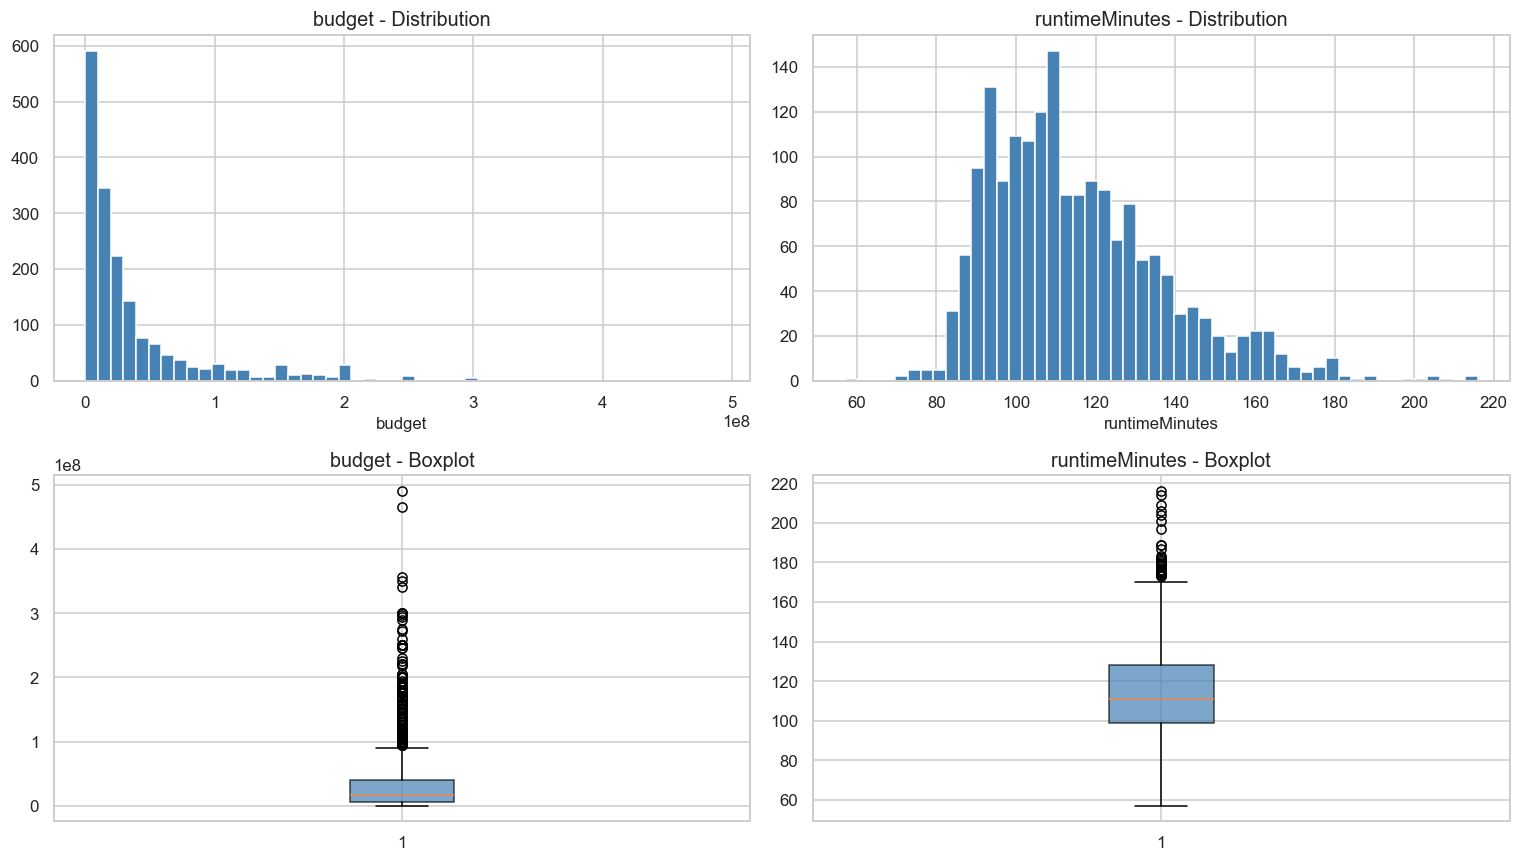

Phim có budget < $10,000: 5 dòng (0.28%)


In [88]:
# Các biến numeric cần kiểm tra: budget, runtimeMinutes

numeric_cols = ['budget', 'runtimeMinutes']

print(df[numeric_cols].describe().round(2))

print("\nSkewness:")
for col in numeric_cols:
    print(f"  {col}: {df[col].skew():.2f}")

# Visualize phân phối + outlier
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for i, col in enumerate(numeric_cols):
    # Histogram
    axes[0, i].hist(df[col].dropna(), bins=50, color='steelblue', edgecolor='white')
    axes[0, i].set_title(f'{col} - Distribution')
    axes[0, i].set_xlabel(col)
    
    # Boxplot
    axes[1, i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                       boxprops=dict(facecolor='steelblue', alpha=0.7))
    axes[1, i].set_title(f'{col} - Boxplot')

plt.tight_layout()
plt.show()

min_bud = 10000
low_budget = df[(df['budget'] < min_bud) & (df['budget'] > 0)]
print(f"Phim có budget < ${min_bud:,}: {len(low_budget)} dòng ({len(low_budget)/len(df)*100:.2f}%)")

budget: phân phối right-skewed nặng (2.78), nhưng phản ánh đặc tính thực của ngành (phim bom tấn...). Xử lý bằng power transform ở các bước sau. Vì thực tế có thể có phim tự quay, kinh phí thấp... nên tạm thời vẫn giữ, đến bước transform sẽ xem xét thêm

runtimeMinutes: nằm trong phạm vi thực tế.

##### 2. Univariate Analysis

**Biến mục tiêu: profitable**

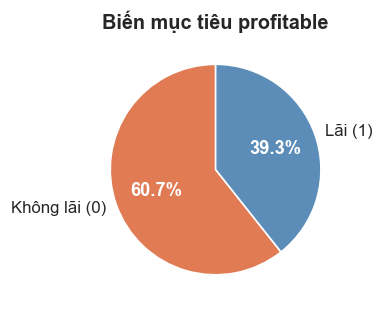

Lãi       (1): 700 (39.3%)
Không lãi (0): 1,080 (60.7%)
Tỷ lệ: 1.54:1


In [89]:
target_counts = df['profitable'].value_counts()
target_pct    = df['profitable'].value_counts(normalize=True)

fig, ax = plt.subplots(figsize=(4, 3))
labels = ['Không lãi (0)', 'Lãi (1)']
colors = [C0, C1]
sizes = [target_counts[0], target_counts[1]]
explode = (0.001, 0.001)

wedges, texts, autotexts = ax.pie(sizes, labels=labels, colors=colors, 
                                    autopct='%1.1f%%', startangle=90,
                                    explode=explode, textprops={'fontsize': 11})

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(12)

ax.set_title('Biến mục tiêu profitable', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Lãi       (1): {target_counts[1]:,} ({target_pct[1]*100:.1f}%)")
print(f"Không lãi (0): {target_counts[0]:,} ({target_pct[0]*100:.1f}%)")
print(f"Tỷ lệ: {target_counts[0]/target_counts[1]:.2f}:1")


Hiện tượng mất cân bằng lớp ở mức độ nhẹ đến trung bình. Nhóm phim không sinh lời chiếm đa số, phản ánh đúng thực tế rủi ro cao của ngành công nghiệp điện ảnh điện ảnh. Tuy nhiên, tỷ lệ 60/40 vẫn là một tỷ lệ phân bổ tương đối lý tưởng cho các mô hình học máy phân loại, không bị rơi vào trạng thái mất cân bằng nghiêm trọng.

Không nhất thiết phải áp dụng các kỹ thuật như oversampling hay undersampling.

**budget**

Thống kê budget (USD):
  count :           1,780
  mean  :      37,820,056
  std   :      54,532,159
  min   :               1
  10%   :       2,600,000
  25%   :       6,110,762
  50%   :      17,200,000
  75%   :      40,000,000
  90%   :     105,000,000
  95%   :     160,000,000
  max   :     489,900,000

Skewness: 2.78
Skewness Log: -1.87
Skewness Cube root: 0.79
Skewness 4th root: 0.47


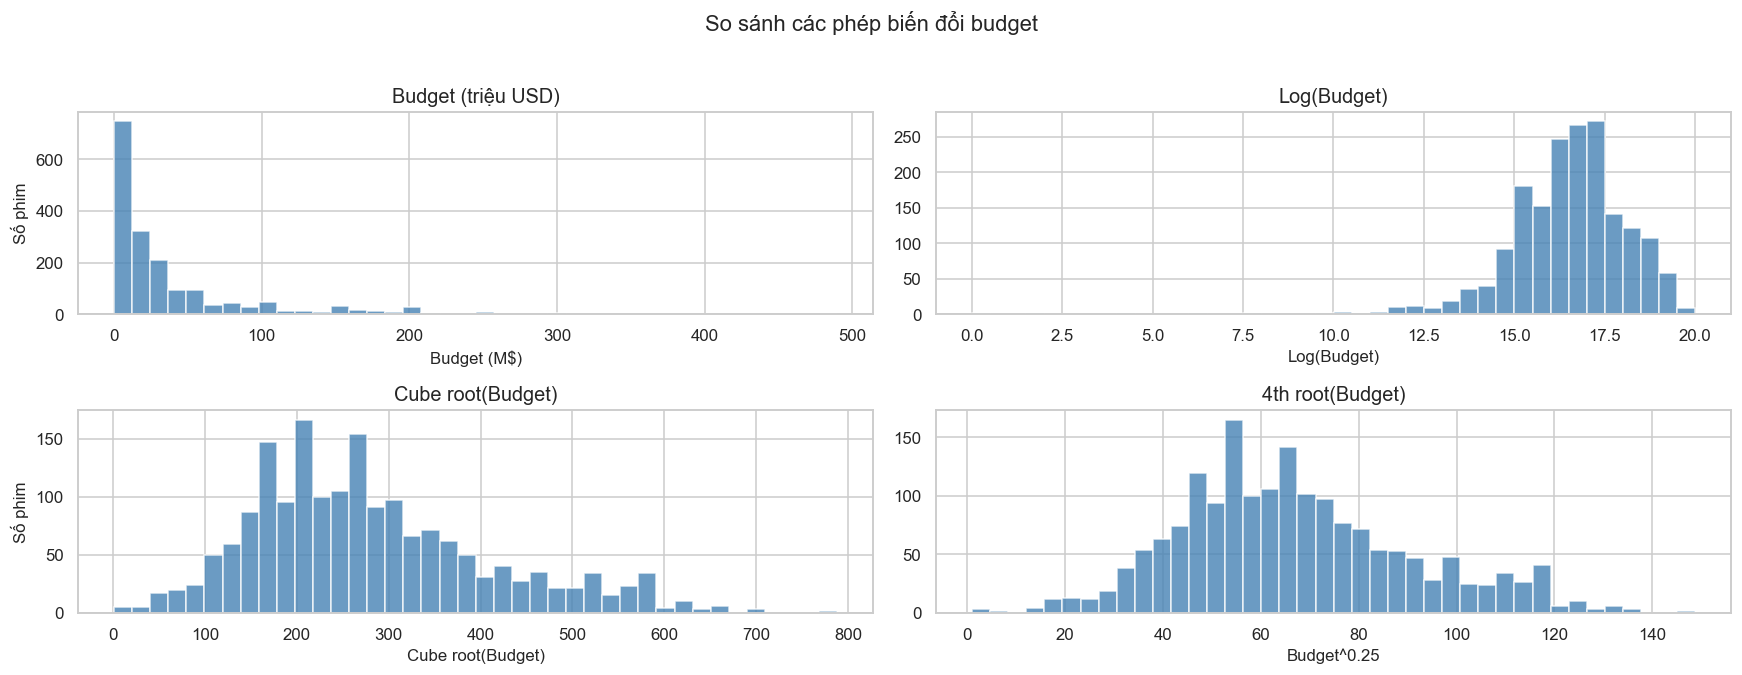

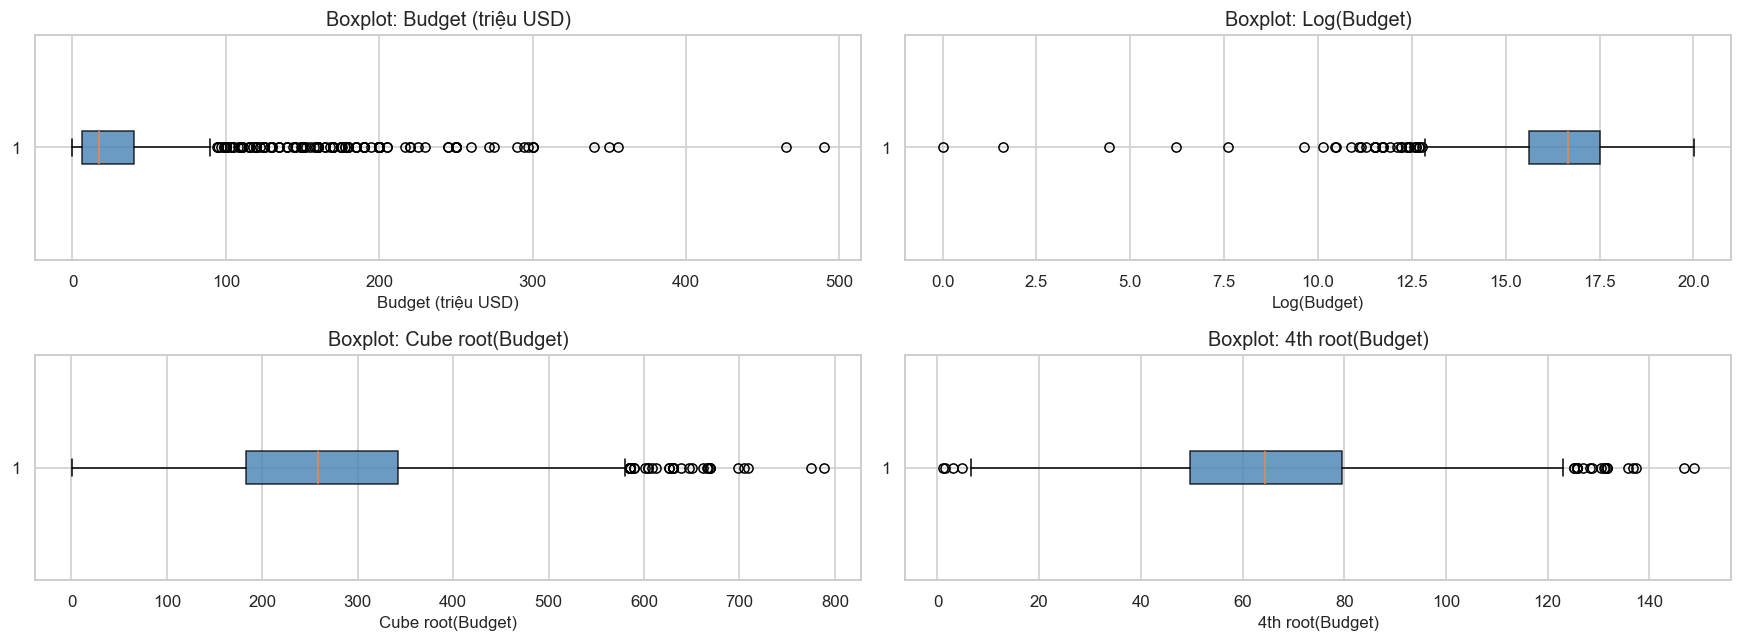

In [90]:
print("Thống kê budget (USD):")
desc = df['budget'].describe(percentiles=[.1, .25, .5, .75, .9, .95])
for k, v in desc.items():
    print(f"  {k:6s}: {v:>15,.0f}")
print(f"\nSkewness: {df['budget'].skew():.2f}")
print(f"Skewness Log: {np.log(df['budget']).skew():.2f}")
print(f"Skewness Cube root: {np.cbrt(df['budget']).skew():.2f}")
print(f"Skewness 4th root: {np.power(df['budget'], 0.25).skew():.2f}")

fig, axes = plt.subplots(2, 2, figsize=(16, 6))

axes[0,0].hist(df['budget']/1e6, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[0,0].set_title('Budget (triệu USD)')
axes[0,0].set_xlabel('Budget (M$)')
axes[0,0].set_ylabel('Số phim')

axes[0,1].hist(np.log(df['budget']), bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[0,1].set_title('Log(Budget)')
axes[0,1].set_xlabel('Log(Budget)')

axes[1,0].hist(np.cbrt(df['budget']), bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[1,0].set_title('Cube root(Budget)')
axes[1,0].set_xlabel('Cube root(Budget)')
axes[1,0].set_ylabel('Số phim')

axes[1,1].hist(np.power(df['budget'], 0.25), bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[1,1].set_title('4th root(Budget)')
axes[1,1].set_xlabel('Budget^0.25')

plt.suptitle('So sánh các phép biến đổi budget', y=1.02)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(16, 6))

axes[0,0].boxplot(df['budget'].dropna()/1e6, vert=False, patch_artist=True, 
                  boxprops=dict(facecolor='steelblue', alpha=0.8))
axes[0,0].set_title('Boxplot: Budget (triệu USD)')
axes[0,0].set_xlabel('Budget (triệu USD)')

axes[0,1].boxplot(np.log(df['budget'].dropna()), vert=False, patch_artist=True,
                  boxprops=dict(facecolor='steelblue', alpha=0.8))
axes[0,1].set_title('Boxplot: Log(Budget)')
axes[0,1].set_xlabel('Log(Budget)')

axes[1,0].boxplot(np.cbrt(df['budget'].dropna()), vert=False, patch_artist=True,
                  boxprops=dict(facecolor='steelblue', alpha=0.8))
axes[1,0].set_title('Boxplot: Cube root(Budget)')
axes[1,0].set_xlabel('Cube root(Budget)')

axes[1,1].boxplot(np.power(df['budget'].dropna(), 0.25), vert=False, patch_artist=True,
                  boxprops=dict(facecolor='steelblue', alpha=0.8))
axes[1,1].set_title('Boxplot: 4th root(Budget)')
axes[1,1].set_xlabel('4th root(Budget)')

plt.tight_layout()
plt.show()

Lệch phải nặng: Giá trị trung bình (~ 37.8 triệu USD) lớn hơn gấp đôi so với trung vị (~ 17.2 triệu USD). Điều này chỉ ra rằng phần lớn các bộ phim trong tập dữ liệu có ngân sách thấp đến trung bình, trong khi phân phối bị kéo một cái đuôi rất dài về phía bên phải bởi một số ít blockbusters.

75% số phim có ngân sách dưới 40 triệu USD. Chỉ có 5% số phim thuộc nhóm siêu bom tấn với mức kinh phí vượt ngưỡng 160 triệu USD.

Các phép biến đổi 

- Logarit: biến đổi dữ liệu từ lệch phải nặng sang lệch trái, do nén quá mạnh các giá trị lớn.

- Căn bậc ba: Giảm đáng kể độ lệch phải.

- Căn bậc bốn: Thu hẹp đáng kể độ lệch phải, hộp IQR nằm tương đối đẹp ở giữa, làm mượt phân phối của cả siêu bom tấn lẫn phim độc lập nhỏ.

Nhóm sẽ transform bằng căn bậc 4 và dùng RobustScaler sau khi transform cho biến budget.

Cần chuẩn hóa giá trị tiền tệ nhằm quy đổi ngân sách từ năm phát hành về sức mua tương đương của năm 2025, để loại bỏ sự sai lệch do thay đổi giá trị đồng tiền theo thời gian. Thực hiện ở bước Feature engineering.

**runtimeMinutes: thời lượng phim**

Thống kê runtimeMinutes:
count    1780.0
mean      115.5
std        22.0
min        57.0
5%         88.0
25%        99.0
50%       111.0
75%       128.0
95%       159.0
max       216.0
Name: runtimeMinutes, dtype: float64

Skewness: 0.94


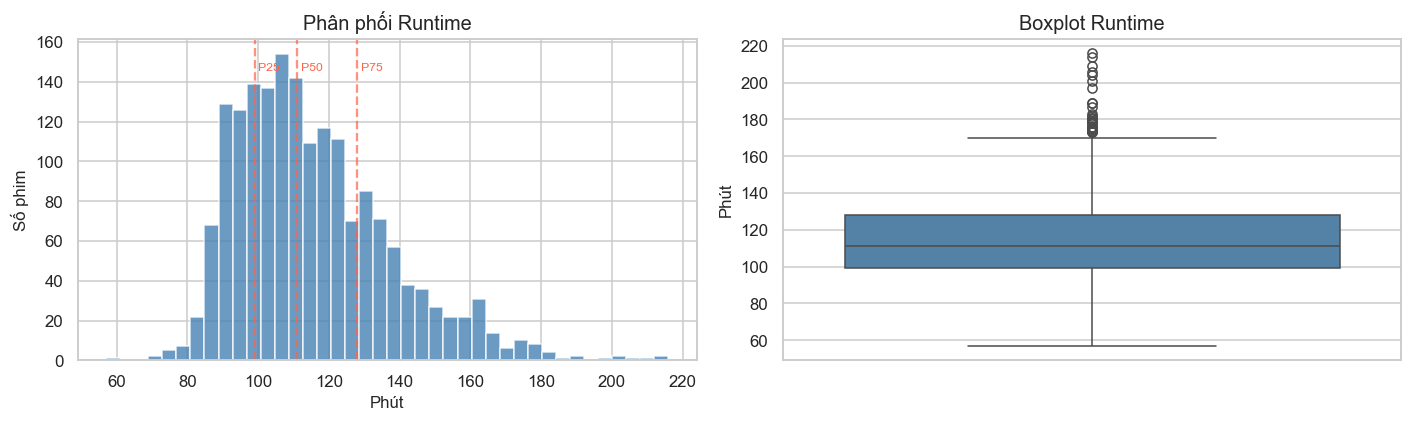

In [91]:
print("Thống kê runtimeMinutes:")
print(df['runtimeMinutes'].describe(percentiles=[.05, .25, .5, .75, .95]).round(1))
print(f"\nSkewness: {df['runtimeMinutes'].skew():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['runtimeMinutes'].dropna(), bins=40, color='steelblue', edgecolor='white', alpha=0.8)
for pct, val in [('P25', df['runtimeMinutes'].quantile(.25)),
                 ('P50', df['runtimeMinutes'].median()),
                 ('P75', df['runtimeMinutes'].quantile(.75))]:
    axes[0].axvline(val, ls='--', color='tomato', alpha=0.7)
    axes[0].text(val+1, axes[0].get_ylim()[1]*0.9, pct, fontsize=8, color='tomato')
axes[0].set_title('Phân phối Runtime')
axes[0].set_xlabel('Phút')
axes[0].set_ylabel('Số phim')

sns.boxplot(y=df['runtimeMinutes'].dropna(), ax=axes[1], color='steelblue')
axes[1].set_title('Boxplot Runtime')
axes[1].set_ylabel('Phút')

plt.tight_layout()
plt.show()

Lệch phải vừa phải, skewness ở mức 0.94. Giá trị trung vị (111 phút) và trung bình (115.5 phút) khá sát nhau. Điều này cho thấy dữ liệu tập trung quanh một trung tâm cố định và chỉ bị kéo nhẹ về phía bên phải.

50% số phim trong tập dữ liệu (khoảng IQR từ Q1 đến Q3) nằm trong khoảng từ 99 đến 128 phút, khung thời lượng tương đối lý tưởng cho phim rạp. Phim ngắn nhất là 57 phút (vẫn hợp lệ), trong khi phim dài nhất lên tới 216 phút (khoảng 3.6 tiếng).

Biểu đồ Boxplot sử dụng quy tắc mặc định $1.5 \times \text{IQR}$ đã gắn nhãn "outlier" cho toàn bộ các bộ phim có thời lượng vượt quá khoảng $128+(1.5 \times (128 - 99))=171.5$ phút. Tuy nhiên các phim thời lượng dài ở trên đại diện cho một số nhóm phim hoàn toàn có thật trong thực tế, không phải lỗi dữ liệu. Vẫn giữ các giá trị này.

Chỉ cần áp dụng chuẩn hóa cơ bản như RobustScaler (sử dụng Median và IQR để hạn chế ảnh hưởng từ nhóm phim dài trên 170 phút) nếu sử dụng các mô hình dựa trên khoảng cách, tuyến tính.

**Các biến categorical và đếm**

In [92]:
# original_language

all_languages = df['original_language'].explode()

print(f"Tổng số ngôn ngữ unique: {all_languages.nunique()}")

print("Thống kê số lượng phim theo từng ngôn ngữ:")
print(all_languages.value_counts())

# origin_country

all_countries = df['origin_country'].explode()

print(f"Tổng số country unique: {all_countries.nunique()}")

print("Thống kê số lượng phim theo từng country:")
print(all_countries.value_counts())

Tổng số ngôn ngữ unique: 39
Thống kê số lượng phim theo từng ngôn ngữ:
original_language
en    1331
hi      98
fr      69
ko      31
es      30
te      29
ta      27
ja      19
zh      18
it      18
ru      15
ml      14
no      10
kn       6
fi       6
da       6
tr       5
pl       4
sv       4
de       4
id       3
hu       3
pt       3
cn       3
bn       2
nl       2
fa       2
ro       2
pa       2
th       2
uk       2
ca       2
ar       2
ga       1
cs       1
mr       1
is       1
la       1
lv       1
Name: count, dtype: int64
Tổng số country unique: 59
Thống kê số lượng phim theo từng country:
origin_country
US    1206
IN     180
GB     170
FR      92
CA      60
KR      33
ES      33
AU      28
CN      24
IT      22
JP      21
BE      17
RU      15
IE      13
HK      12
DK      11
NO      11
DE      10
FI       8
SE       7
PL       6
TR       5
HU       4
LU       4
TH       4
MX       4
CH       4
ID       3
RO       3
IS       3
NZ       3
AT       3
BR       3
UA       

original_language: một số ngôn ngữ chỉ xuất hiện từ 1 đến 2 lần trong toàn bộ tập dữ liệu. Sẽ thực hiện gom các nhóm ít xuất hiện thành other, chỉ giữ lại top các ngôn ngữ xuất hiện nhiều nhất. Chi tiết xử lý ở bước encoding

origin_country hiện tại đang là list quốc gia đồng sản xuất (nếu có). Nhóm thực hiện trích xuất 1 nước làm thị trường chính, tạo thành biến primary_country (phần này thực hiện ở bước feature engineering). Sau đó đối với primary_country, xử lý tương tự như original_language đã trình bày ở mục trước, gom các quốc gia ít xuất hiện thành other...

In [93]:
# genres

exploded_genres = df['genres'].explode()
print(exploded_genres.value_counts())
print(exploded_genres.nunique())

genres
18       827
35       536
28       535
53       491
12       347
27       288
80       255
10749    228
878      224
14       195
10751    170
9648     158
36       151
16       131
10752     68
10402     59
37        22
99        12
10770      1
Name: count, dtype: int64
19


Có tổng cộng 19 unique genres, nhưng 1 phim có thể có nhiều genres, nhóm quyết định sẽ drop các cột ít sample sau khi multihot encoding. Xử lý ở bước encoding.

In [94]:
# certification_us

print(df['certification_us'].value_counts(dropna=False))

certification_us
R        724
PG-13    485
NaN      258
PG       199
NR       111
G          3
Name: count, dtype: int64


Các nhãn ít xuất hiện sẽ được gom chung với nhãn tương đồng (G và PG, NC-17 và R). Xử lý ở bước encoding.

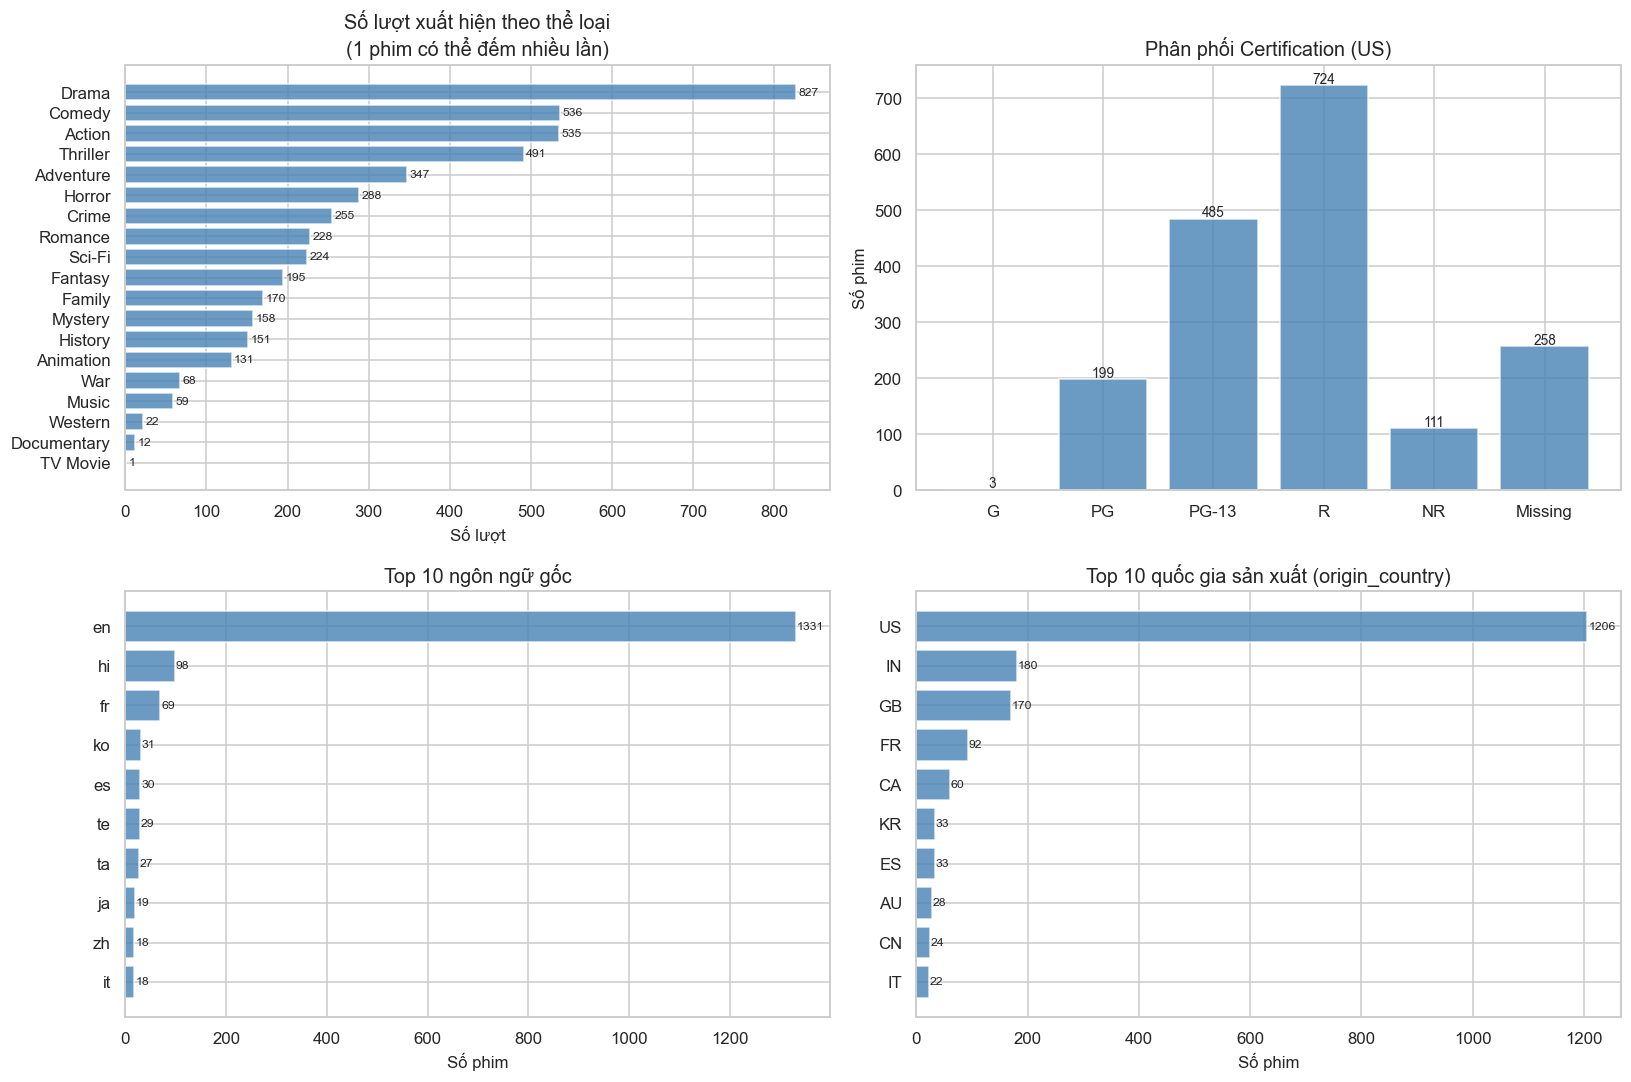

In [95]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Genres (explode - một phim được đếm nhiều lần nếu có nhiều genre)
genre_counts = df['genres_named'].explode().value_counts()
axes[0, 0].barh(genre_counts.index[::-1], genre_counts.values[::-1], color='steelblue', alpha=0.8)
axes[0, 0].set_title('Số lượt xuất hiện theo thể loại\n(1 phim có thể đếm nhiều lần)')
axes[0, 0].set_xlabel('Số lượt')
for i, v in enumerate(genre_counts.values[::-1]):
    axes[0, 0].text(v + 3, i, str(v), va='center', fontsize=8)

# Certification
cert_counts = df['certification_us'].fillna('Missing').value_counts()
cert_display_order = [c for c in ['G','PG','PG-13','R','NR','NC-17','Missing'] if c in cert_counts.index]
axes[0, 1].bar(cert_display_order,
               [cert_counts[c] for c in cert_display_order],
               color='steelblue', alpha=0.8, edgecolor='white')
axes[0, 1].set_title('Phân phối Certification (US)')
axes[0, 1].set_ylabel('Số phim')
for i, c in enumerate(cert_display_order):
    axes[0, 1].text(i, cert_counts[c] + 3, str(cert_counts[c]), ha='center', fontsize=9)

# Language - top N_LANG
lang_counts_train = df['original_language'].value_counts().head(N_LANG)
axes[1, 0].barh(lang_counts_train.index[::-1], lang_counts_train.values[::-1], color='steelblue', alpha=0.8)
axes[1, 0].set_title(f'Top {N_LANG} ngôn ngữ gốc')
axes[1, 0].set_xlabel('Số phim')
for i, v in enumerate(lang_counts_train.values[::-1]):
    axes[1, 0].text(v + 2, i, str(v), va='center', fontsize=8)

# Country - top N_COUNTRY
country_counts_train = df['origin_country'].explode().value_counts().head(N_COUNTRY)
axes[1, 1].barh(country_counts_train.index[::-1], country_counts_train.values[::-1], color='steelblue', alpha=0.8)
axes[1, 1].set_title(f'Top {N_COUNTRY} quốc gia sản xuất (origin_country)')
axes[1, 1].set_xlabel('Số phim')
for i, v in enumerate(country_counts_train.values[::-1]):
    axes[1, 1].text(v + 2, i, str(v), va='center', fontsize=8)

plt.tight_layout()
plt.show()

Genres là biến đa nhãn (Multi-label), một bộ phim có thể thuộc nhiều thể loại cùng lúc. Do đó, tổng số lượng đếm ở biểu đồ này sẽ lớn hơn tổng số phim thực tế. 

Ba thể loại Drama, Comedy, và Action chiếm ưu thế. Thể loại Documentary xuất hiện rất ít.

Vì 1 phim có thể có nhiều thể loại nên nhóm sẽ sử dụng MultiHot encoding cho biến genres. Các thể loại xuất hiện quá ít có thể xem xét drop.

Certification (US): Phim dán nhãn R và PG-13 chiếm đại đa số. Nhãn G chỉ có vỏn vẹn 3 phim. Có 258 phim bị khuyết nhãn kiểm duyệt. Dự kiến sẽ xử lý missing thành NR, gom chung các nhãn tương đồng như PG và G và thực hiện One-Hot Encoding.

Language & Country: Tiếng Anh (en) chiếm tới 1,331 phim (gần 75% tập dữ liệu) và Mỹ (US) đứng đầu danh sách quốc gia với 1,206 phim, cho thấy sự thống trị của Hollywood. Theo sau ở khoảng cách rất xa là Ấn Độ (IN / hi) đại diện cho nền công nghiệp Bollywood.

Đối với các biến original_language và primary_country, việc để quá nhiều danh mục nhỏ (như it, zh, tr, CA...) sẽ làm bùng nổ số lượng cột khi mã hóa One-Hot Encoding. Nhóm sẽ chỉ giữ một số các giá trị top, gom các danh mục còn lại vào nhóm other.

**n_keywords và production_companies: phân phối số lượng (count)**

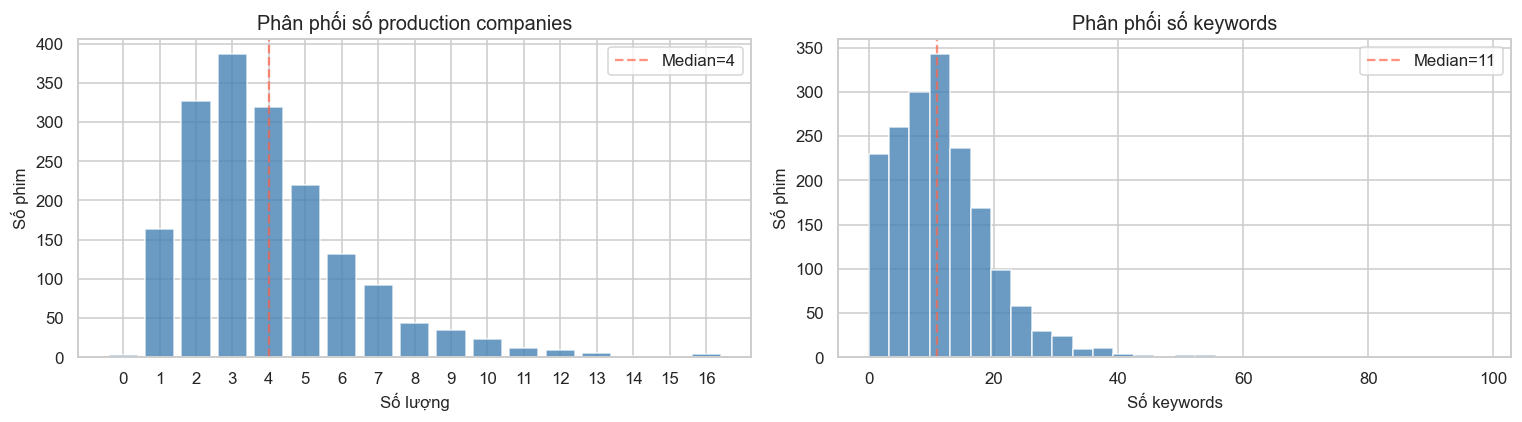

n_pc       - min: 0, median: 4, max: 16
n_keywords - min: 0, median: 11, max: 98
Phim không có production company: 3 (0.2%)
Phim không có keyword: 70 (3.9%)


In [96]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

pc_vc = df['n_pc'].value_counts().sort_index()
axes[0].bar(pc_vc.index, pc_vc.values, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].set_title('Phân phối số production companies')
axes[0].set_xlabel('Số lượng')
axes[0].set_ylabel('Số phim')
axes[0].set_xticks(pc_vc.index)
axes[0].axvline(df['n_pc'].median(), ls='--', color='tomato', alpha=0.7,
                label=f"Median={df['n_pc'].median():.0f}")
axes[0].legend()

axes[1].hist(df['n_keywords'], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(df['n_keywords'].median(), ls='--', color='tomato', alpha=0.7,
                label=f"Median={df['n_keywords'].median():.0f}")
axes[1].set_title('Phân phối số keywords')
axes[1].set_xlabel('Số keywords')
axes[1].set_ylabel('Số phim')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"n_pc       - min: {df['n_pc'].min()}, median: {df['n_pc'].median():.0f}, max: {df['n_pc'].max()}")
print(f"n_keywords - min: {df['n_keywords'].min()}, median: {df['n_keywords'].median():.0f}, max: {df['n_keywords'].max()}")
print(f"Phim không có production company: {(df['n_pc']==0).sum()} ({(df['n_pc']==0).mean()*100:.1f}%)")
print(f"Phim không có keyword: {(df['n_keywords']==0).sum()} ({(df['n_keywords']==0).mean()*100:.1f}%)")

Mỗi phim có khá nhiều production company và keyword, dự kiến sẽ dùng frequency encoding và tính điểm sum, max, count.

Tổng số NSX unique: 3192

 Số phim tham gia  Số lượng NSX  % trên tổng số NSX unique  Cumulative_NSX  Cumulative_%
                1          2143                      67.14            2143         67.14
                2           482                      15.10            2625         82.24
                3           199                       6.23            2824         88.47
                4           108                       3.38            2932         91.85
                5            56                       1.75            2988         93.61
                6            30                       0.94            3018         94.55
                7            33                       1.03            3051         95.58
                8            31                       0.97            3082         96.55
                9            14                       0.44            3096         96.99
               10            13                       0.41            3109         9

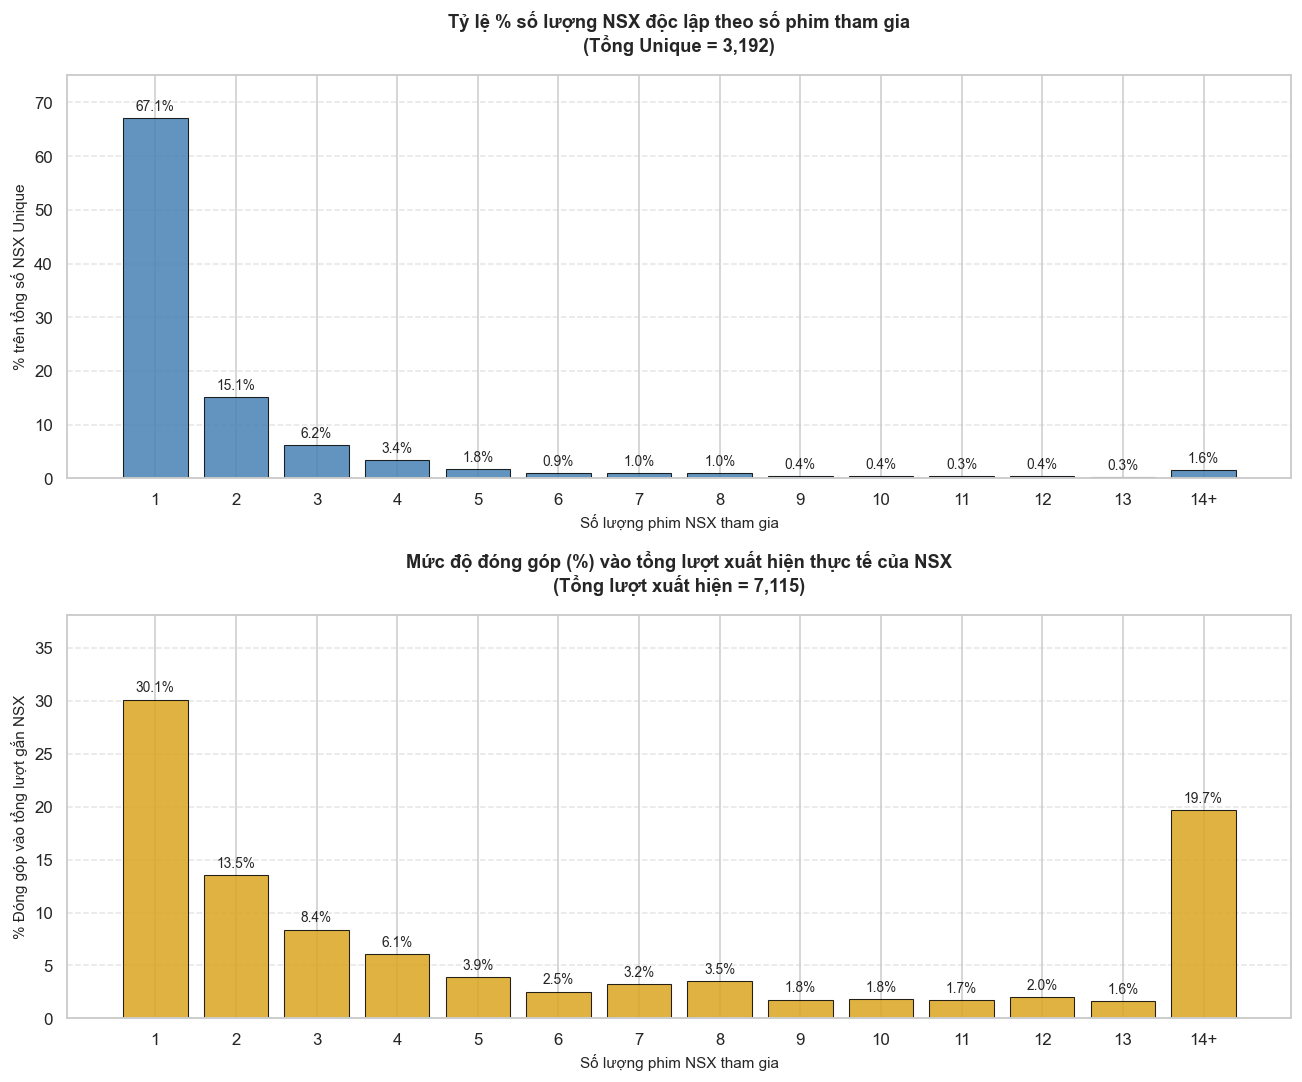

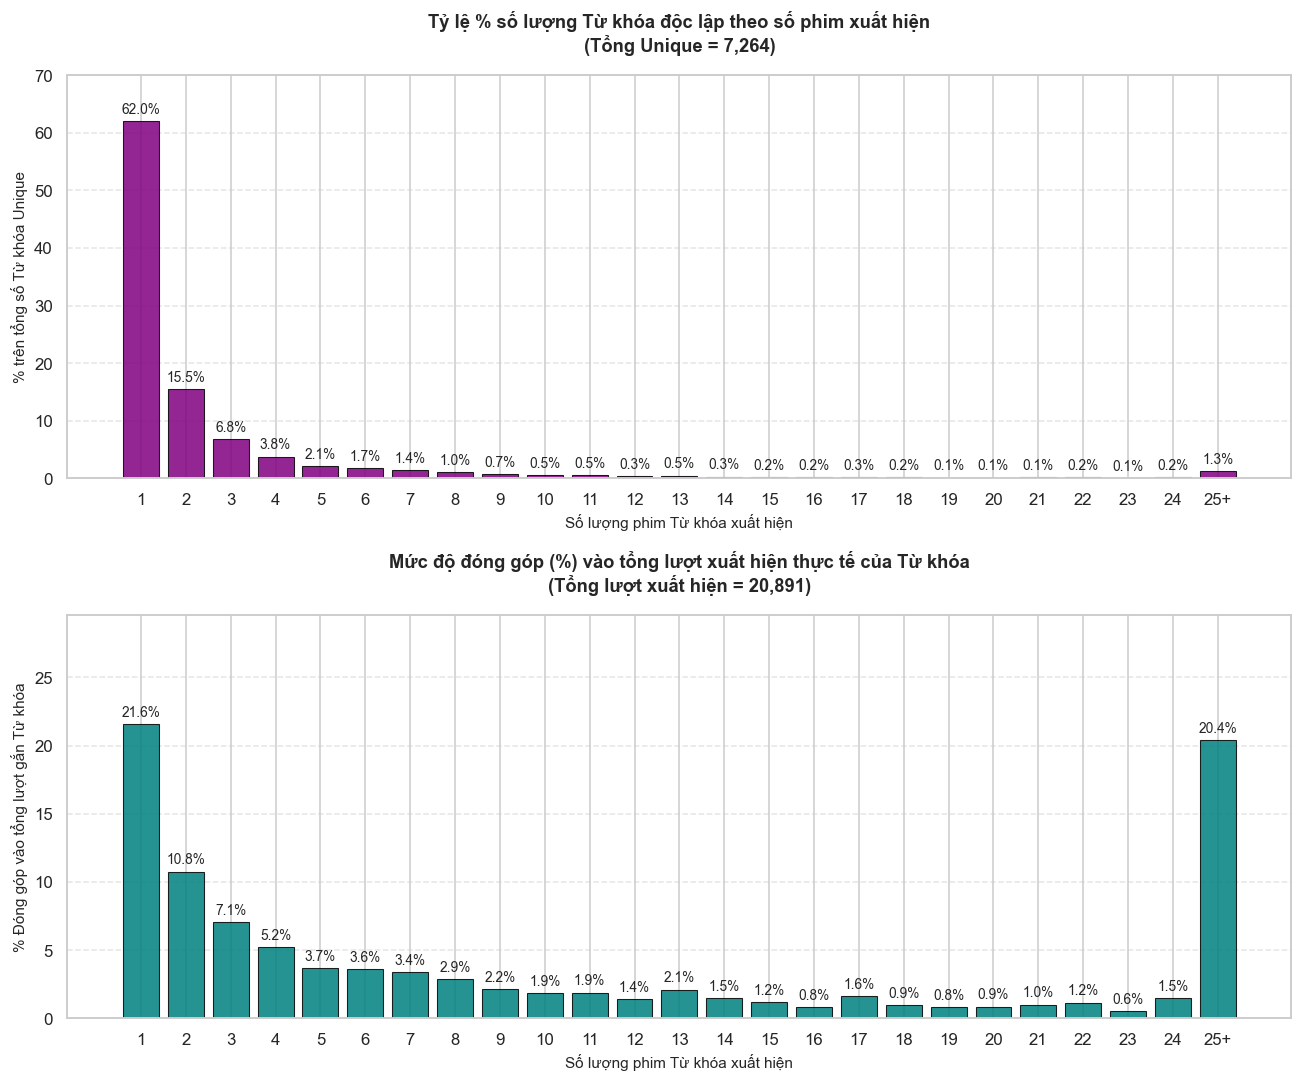

In [97]:
def analyze_frequency(series, entity_name, action_col, threshold_text, threshold):
    all_items = series.explode()
    counts = all_items.value_counts()

    frequency_distribution = counts.value_counts().sort_index()
    total_unique = len(counts)

    df_freq = pd.DataFrame({
        f'Số phim {action_col}': frequency_distribution.index,
        f'Số lượng {entity_name}': frequency_distribution.values
    })
    
    df_freq[f'% trên tổng số {entity_name} unique'] = (df_freq[f'Số lượng {entity_name}'] / total_unique * 100).round(2)
    df_freq[f'Cumulative_{entity_name}'] = df_freq[f'Số lượng {entity_name}'].cumsum()
    df_freq['Cumulative_%'] = (df_freq[f'Cumulative_{entity_name}'] / total_unique * 100).round(2)

    print(f"Tổng số {entity_name} unique: {total_unique}\n")
    print(df_freq.to_string(index=False))

    eligible = counts[counts >= threshold]
    pct = len(eligible) / total_unique * 100
    print(f"\n{threshold_text} {threshold} phim: {len(eligible)} / {total_unique} ({pct:.2f}%)\n")
    
    return counts, df_freq

counts_nsx, df_freq_nsx = analyze_frequency(
    series=df['production_companies'],
    entity_name='NSX',
    action_col='tham gia',
    threshold_text='NSX tham gia >=',
    threshold=2
)

counts_kw, df_freq_kw = analyze_frequency(
    series=df['keywords'],
    entity_name='keyword',
    action_col='xuất hiện',
    threshold_text='Keyword xuất hiện trong >=',
    threshold=3
)

def plot_entity_distribution(
    df, column_name, threshold, entity_label, entity_label2, c0="steelblue", c1="goldenrod"
):
    all_entities = df[column_name].explode().dropna()
    counts = all_entities.value_counts()

    total_unique = len(counts)
    total_appearances = counts.sum()

    freq_dist = counts.value_counts().sort_index()
    df_raw = pd.DataFrame(
        {
            "Số phim tham gia": freq_dist.index,
            "Số lượng dòng": freq_dist.values,
        }
    )

    def binning_tail(x):
        if x < threshold:
            return str(x)
        else:
            return f"{threshold}+"

    df_raw["Nhóm"] = df_raw["Số phim tham gia"].apply(binning_tail)

    df_raw["Tổng lượt xuất hiện đóng góp"] = (
        df_raw["Số phim tham gia"] * df_raw["Số lượng dòng"]
    )

    df_plot = (
        df_raw.groupby("Nhóm")
        .agg(
            {
                "Số lượng dòng": "sum",
                "Tổng lượt xuất hiện đóng góp": "sum",
                "Số phim tham gia": "min",
            }
        )
        .reset_index()
    )

    df_plot["% trên tổng số unique"] = (
        df_plot["Số lượng dòng"] / total_unique * 100
    )
    df_plot["% độ phủ"] = (
        df_plot["Tổng lượt xuất hiện đóng góp"] / total_appearances * 100
    )

    order = [str(i) for i in range(1, threshold)] + [f"{threshold}+"]
    df_plot["Nhóm"] = pd.Categorical(df_plot["Nhóm"], categories=order, ordered=True)
    df_plot = df_plot.sort_values("Nhóm")

    fig, axes = plt.subplots(2, 1, figsize=(12, 10))

    bars1 = axes[0].bar(
        df_plot["Nhóm"],
        df_plot["% trên tổng số unique"],
        color=c0,
        alpha=0.85,
        edgecolor="black",
        linewidth=0.7,
    )
    axes[0].set_title(
        f"Tỷ lệ % số lượng {entity_label} độc lập theo số phim {entity_label2}\n(Tổng Unique = {total_unique:,})",
        fontsize=12,
        fontweight="bold",
        pad=15,
    )
    axes[0].set_xlabel(f"Số lượng phim {entity_label} {entity_label2}", fontsize=10)
    axes[0].set_ylabel(f"% trên tổng số {entity_label} Unique", fontsize=10)
    axes[0].set_ylim(0, df_plot["% trên tổng số unique"].max() + 8)
    axes[0].bar_label(bars1, fmt="%.1f%%", padding=3, fontsize=9)
    axes[0].grid(axis="y", linestyle="--", alpha=0.5)

    bars2 = axes[1].bar(
        df_plot["Nhóm"],
        df_plot["% độ phủ"],
        color=c1,
        alpha=0.85,
        edgecolor="black",
        linewidth=0.7,
    )
    axes[1].set_title(
        f"Mức độ đóng góp (%) vào tổng lượt xuất hiện thực tế của {entity_label}\n(Tổng lượt xuất hiện = {total_appearances:,})",
        fontsize=12,
        fontweight="bold",
        pad=15,
    )
    axes[1].set_xlabel(f"Số lượng phim {entity_label} {entity_label2}", fontsize=10)
    axes[1].set_ylabel(
        f"% Đóng góp vào tổng lượt gắn {entity_label}", fontsize=10
    )
    axes[1].set_ylim(0, df_plot["% độ phủ"].max() + 8)
    axes[1].bar_label(bars2, fmt="%.1f%%", padding=3, fontsize=9)
    axes[1].grid(axis="y", linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()

plot_entity_distribution(
    df=df,
    column_name="production_companies",
    threshold=14,
    entity_label="NSX",
    entity_label2="tham gia",
    c0="steelblue",
    c1="goldenrod",
)

plot_entity_distribution(
    df=df,
    column_name="keywords",
    threshold=25,
    entity_label="Từ khóa",
    entity_label2="xuất hiện",
    c0="purple",
    c1="teal",
)

Hơn 67% số lượng id production_companies unique chỉ xuất hiện 1 lần. 62% số lượng id keywords unique chỉ xuất hiện 1 lần. Các entity xuất hiện 1-2 lần có frequency gần 0 và không mang thông tin thống kê đáng tin cậy, nhưng chúng chiếm phần lớn unique values.

Xử lý: ở bước frequency encoding, nhóm sẽ bỏ qua các entity dưới ngưỡng tần suất tối thiểu, các rare entity này sẽ được coi như frequency = 0

**release_year và release_month**

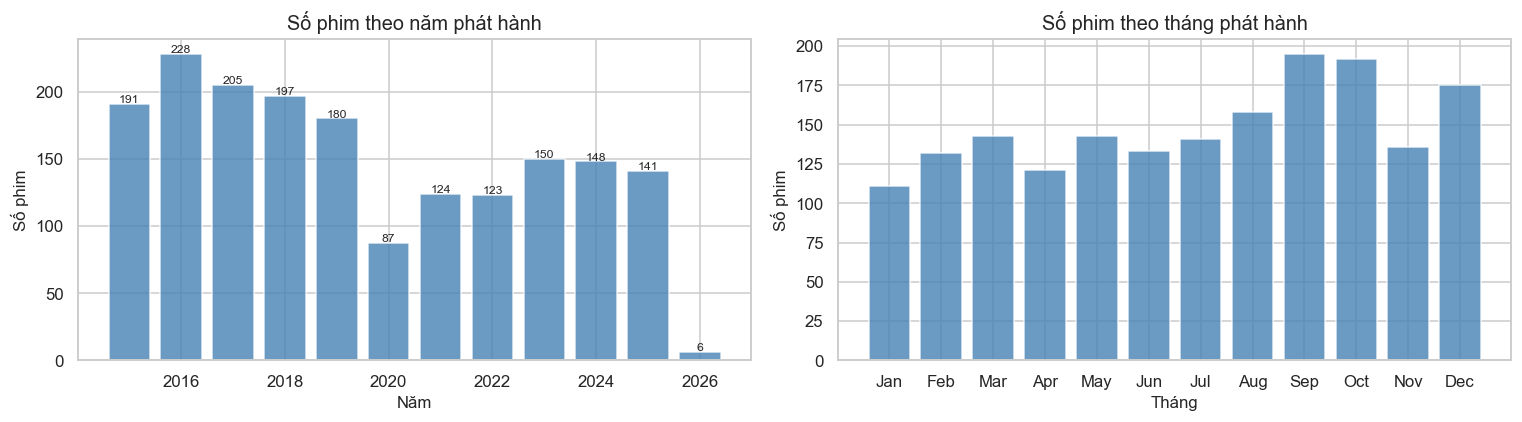

In [98]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

year_counts = df['release_year'].value_counts().sort_index()
axes[0].bar(year_counts.index, year_counts.values, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].set_title('Số phim theo năm phát hành')
axes[0].set_xlabel('Năm')
axes[0].set_ylabel('Số phim')
for x, v in zip(year_counts.index, year_counts.values):
    axes[0].text(x, v + 1, str(v), ha='center', fontsize=8)

month_counts = df['release_month'].value_counts().sort_index()
month_names  = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
axes[1].bar(month_names, [month_counts.get(i, 0) for i in range(1, 13)],
            color='steelblue', alpha=0.8, edgecolor='white')
axes[1].set_title('Số phim theo tháng phát hành')
axes[1].set_xlabel('Tháng')
axes[1].set_ylabel('Số phim')

plt.tight_layout()
plt.show()

Năm: Giai đoạn 2015-2019: số lượng phim cao ổn định (180-230/năm). 2020-2021: drop mạnh có thể liên quan đến COVID. Phục hồi từ 2023.

Tháng: 9, 10 & 12: Số lượng phim vọt lên cao, đặc biệt là tháng 9 và tháng 10. 

##### 3. Bivariate: Numerical vs Target

**budget vs profitable**

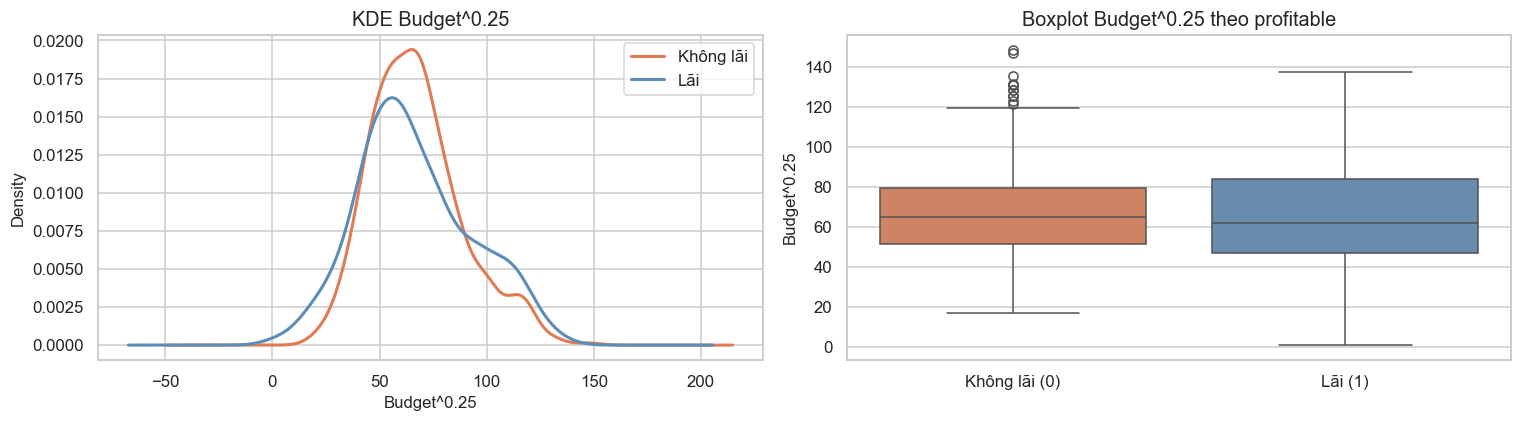

Median budget - Không lãi: 18,000,000
Median budget - Lãi      : 15,000,000


In [99]:
budget_0 = df[df['profitable']==0]['budget']
budget_1 = df[df['profitable']==1]['budget']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for label, data, color in [('Không lãi', budget_0, C0), ('Lãi', budget_1, C1)]:
    np.power(data[data > 0], 0.25).plot.kde(ax=axes[0], label=label, color=color, lw=2)
axes[0].set_title(f'KDE Budget^0.25')
axes[0].set_xlabel('Budget^0.25')
axes[0].legend()

plot_df = df[['profitable','budget']].copy()
plot_df['budget_t'] = np.power(plot_df['budget'], 0.25)
sns.boxplot(data=plot_df, x='profitable', y='budget_t', ax=axes[1],
            palette={'0': C0, '1': C1})
axes[1].set_title('Boxplot Budget^0.25 theo profitable')
axes[1].set_xticklabels(['Không lãi (0)', 'Lãi (1)'])
axes[1].set_xlabel('')
axes[1].set_ylabel('Budget^0.25')

plt.tight_layout()
plt.show()

print(f"Median budget - Không lãi: {budget_0.median():,.0f}")
print(f"Median budget - Lãi      : {budget_1.median():,.0f}")

Trung vị mức đầu tư của nhóm phim lỗ lại cao hơn phim lời khoảng 3 triệu USD. Đường mật độ của 2 nhóm phim tương đối giống nhau. 

**runtimeMinutes vs profitable**

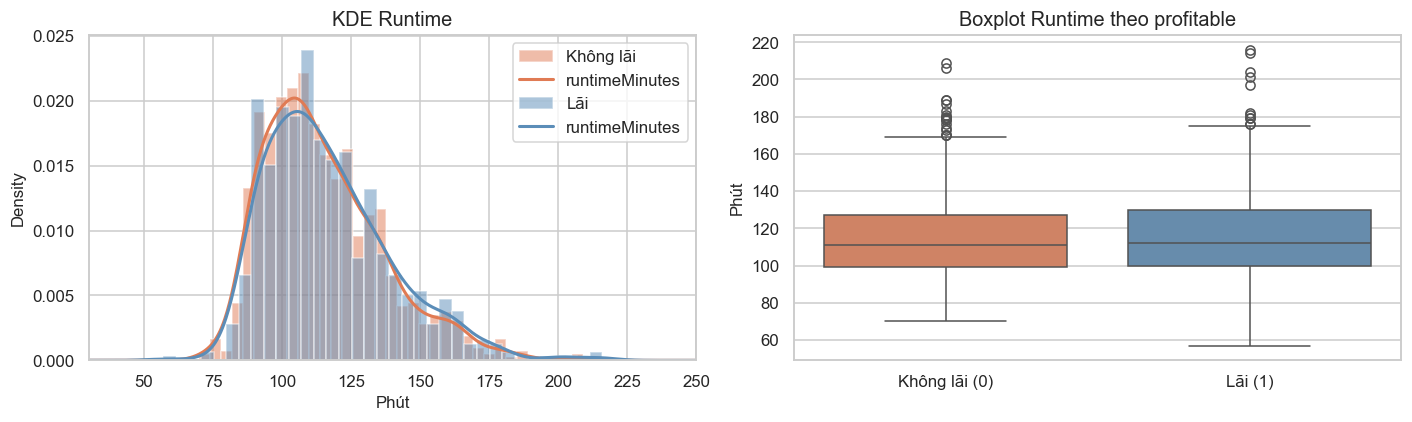

Median runtime - Không lãi: 111 phút | Lãi: 112 phút


In [100]:
runtime_0 = df[df['profitable']==0]['runtimeMinutes'].dropna()
runtime_1 = df[df['profitable']==1]['runtimeMinutes'].dropna()
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for label, data, color in [('Không lãi', runtime_0, C0), ('Lãi', runtime_1, C1)]:
    axes[0].hist(data, bins=35, alpha=0.5, color=color, density=True, label=label)
    data.plot.kde(ax=axes[0], color=color, lw=2)
axes[0].set_xlim(30, 250) 
axes[0].set_title(f'KDE Runtime')
axes[0].set_xlabel('Phút')
axes[0].legend()

rt_df = df[['profitable','runtimeMinutes']].dropna()
sns.boxplot(data=rt_df, x='profitable', y='runtimeMinutes', ax=axes[1],
            palette={'0': C0, '1': C1})
axes[1].set_title('Boxplot Runtime theo profitable')
axes[1].set_xticklabels(['Không lãi (0)', 'Lãi (1)'])
axes[1].set_xlabel('')
axes[1].set_ylabel('Phút')

plt.tight_layout()
plt.show()
print(f"Median runtime - Không lãi: {runtime_0.median():.0f} phút | Lãi: {runtime_1.median():.0f} phút")

Biểu đồ mật độ và boxplot rất tương đồng, trung vị chênh lệch rất nhỏ. Gần như không có sự khác biệt có ý nghĩa thống kê giữa thời lượng của hai nhóm phim. Biến này có khả năng sẽ không mang lại quá nhiều thông tin hữu ích.

**release_year vs profitable**

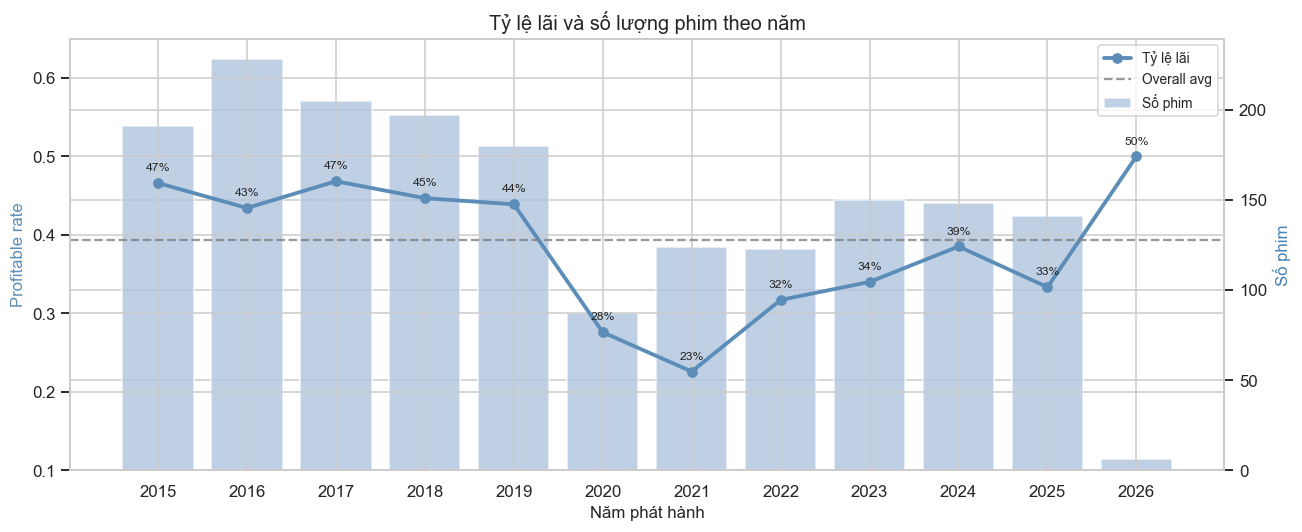

In [101]:
year_rate = df.groupby('release_year')['profitable'].agg(['mean','count']).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()
ax1.set_zorder(ax2.get_zorder() + 1)
ax1.patch.set_visible(False)
ax2.bar(year_rate['release_year'], year_rate['count'],
        color='lightsteelblue', alpha=0.8, label='Số phim')
ax1.plot(year_rate['release_year'], year_rate['mean'],
         marker='o', color=C1, lw=2.5, label='Tỷ lệ lãi')
ax1.axhline(df['profitable'].mean(), ls='--', color='gray', alpha=0.8, label='Overall avg')
for _, row in year_rate.iterrows():
    ax1.annotate(f"{row['mean']*100:.0f}%",
                 (row['release_year'], row['mean']),
                 textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8)
ax1.set_xticks(year_rate['release_year'])
ax1.set_xlabel('Năm phát hành')
ax1.set_ylabel('Profitable rate', color=C1)
ax2.set_ylabel('Số phim', color='steelblue')
ax1.set_ylim(0.1, 0.65)
ax1.set_title('Tỷ lệ lãi và số lượng phim theo năm')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

2015-2019: Số lượng phim sản xuất và tỷ lệ phim có lãi duy trì ổn định ở mức cao so với các năm còn lại.

Số lượng phim sản xuất và tỷ lệ phim có lãi giảm mạnh vào giai đoạn 2020-2021, sau đó phục hồi trở lại từ năm 2022.

**release_month vs profitable**

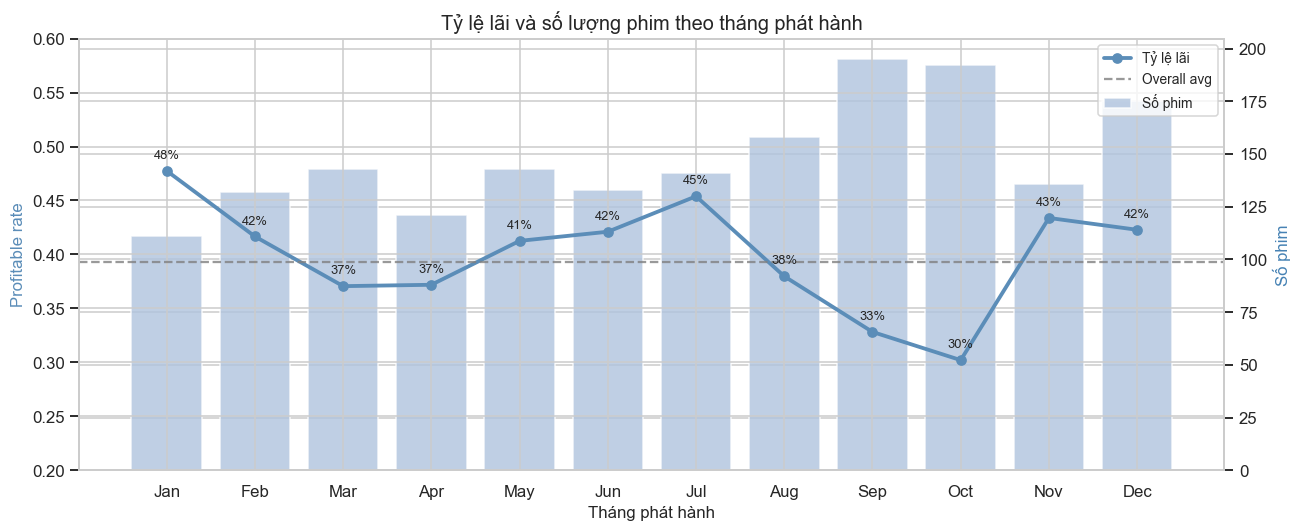

In [102]:
month_rate  = df.groupby('release_month')['profitable'].agg(['mean','count']).reset_index()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.set_zorder(ax2.get_zorder() + 1)
ax1.patch.set_visible(False)
ax2.bar(month_names, month_rate['count'],
        color='lightsteelblue', alpha=0.8, label='Số phim')
ax1.plot(month_names, month_rate['mean'],
         marker='o', color=C1, lw=2.5, label='Tỷ lệ lãi')
ax1.axhline(df['profitable'].mean(), ls='--', color='gray', alpha=0.8, label='Overall avg')
for i, (_, row) in enumerate(month_rate.iterrows()):
    ax1.annotate(f"{row['mean']*100:.0f}%",
                 (i, row['mean']),
                 textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8.5)

ax1.set_xlabel('Tháng phát hành')
ax1.set_ylabel('Profitable rate', color=C1)
ax2.set_ylabel('Số phim', color='steelblue')
ax1.set_ylim(0.2, 0.6)
ax1.set_title('Tỷ lệ lãi và số lượng phim theo tháng phát hành')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

Tháng 9 và Tháng 10 có tỷ lệ lãi thấp nhất năm (lần lượt là 33% và 30%), nằm dưới khá sâu so với mức trung bình. Tuy nhiên, số lượng phim phát hành lại đạt đỉnh (~190 phim/tháng).

Tháng 1 có tỷ lệ lãi cao nhất năm (48%). Ngược lại, số lượng phim phát hành lại ít nhất (~110 phim).

Tháng 7 (45%), Tháng 11 (43%) và Tháng 12 (42%) đều có tỷ lệ lãi khá tốt so với mức trung bình. Đặc biệt là Tháng 12, dù số lượng phim ra mắt rất lớn nhưng tỷ lệ lãi vẫn giữ ở mức cao.

release_month có thể mang lại tín hiệu dự đoán khá tốt.

##### 4. Bivariate: Categorical vs Target

**genres vs profitable**

Cách tính: P(profitable | phim có genre X). Mỗi phim được tính độc lập cho từng genre. Một phim có nhiều genre sẽ đóng góp vào nhiều cột tính riêng biệt.

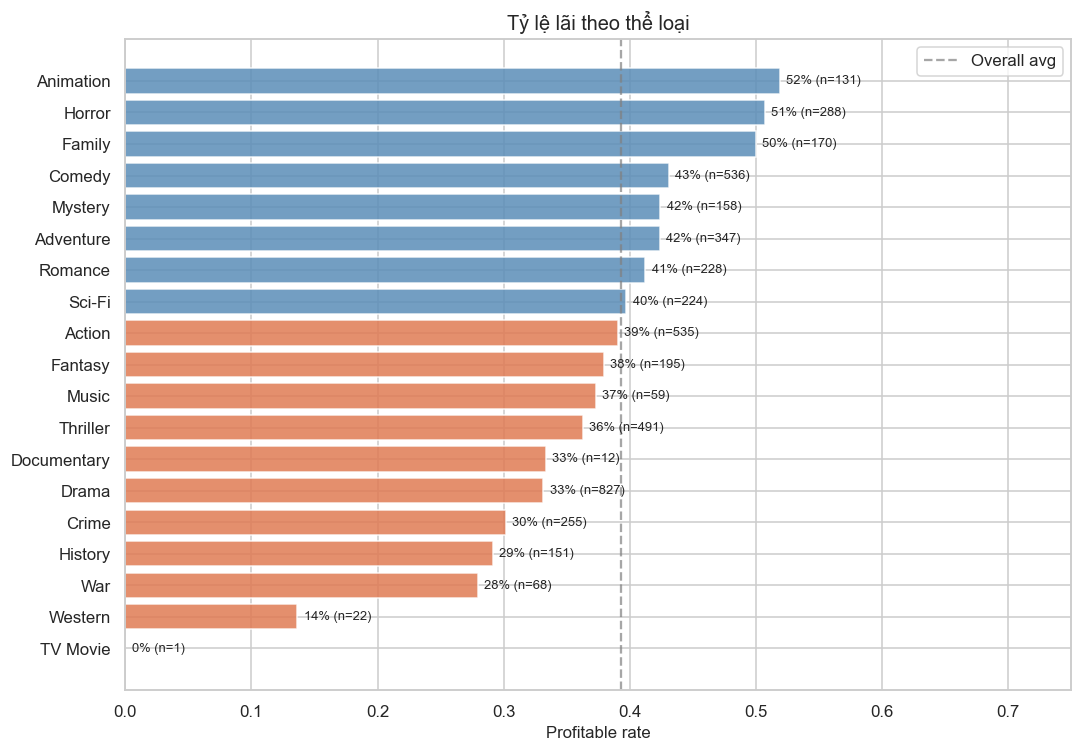

In [103]:
genre_rows = []
for genre_id, genre_name in TMDB_GENRES.items():
    mask  = df['genres'].apply(lambda g: genre_id in g)
    count = mask.sum()
    rate = df[mask]['profitable'].mean()
    genre_rows.append({'genre': genre_name, 'count': count, 'profitable_rate': rate})

genre_df = pd.DataFrame(genre_rows).sort_values('profitable_rate', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors = [C1 if r >= df['profitable'].mean() else C0 for r in genre_df['profitable_rate']]
bars   = ax.barh(genre_df['genre'], genre_df['profitable_rate'],
                 color=colors, alpha=0.85, edgecolor='white')
ax.axvline(df['profitable'].mean(), ls='--', color='gray', alpha=0.7, label='Overall avg')
for bar, (_, row) in zip(bars, genre_df.iterrows()):
    ax.text(row['profitable_rate'] + 0.005, bar.get_y() + bar.get_height()/2,
            f"{row['profitable_rate']*100:.0f}% (n={row['count']})",
            va='center', fontsize=8.5)
ax.set_title('Tỷ lệ lãi theo thể loại')
ax.set_xlabel('Profitable rate')
ax.set_xlim(0, 0.75)
ax.legend()
plt.tight_layout()
plt.show()

Một số nhóm thể loại có tỷ lệ lãi cao hơn. Một số thể loại có tỷ lệ lãi khá thấp, tuy nhiên do lượng mẫu nhỏ nên chưa thể khẳng định.

**certification_us vs profitable**

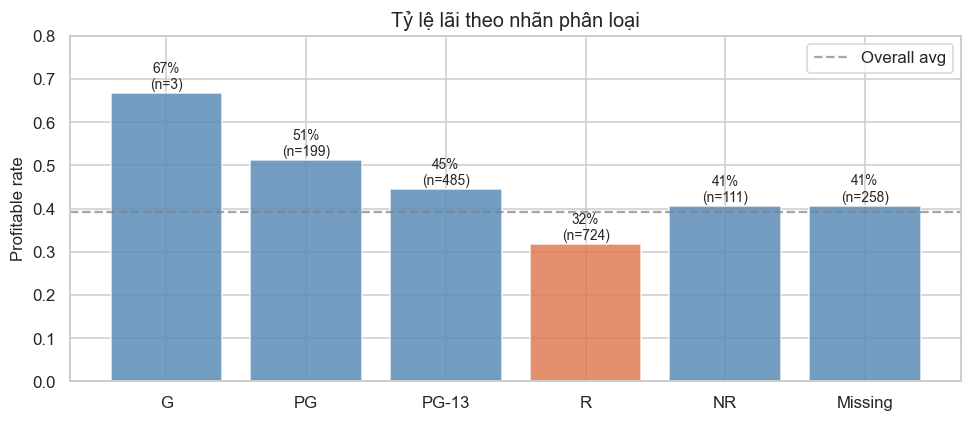

In [104]:
cert_df_bivar = df.copy()
cert_df_bivar['cert_label'] = cert_df_bivar['certification_us'].fillna('Missing')
cert_stats = cert_df_bivar.groupby('cert_label')['profitable'].agg(['mean','count'])
cert_stats = cert_stats.reindex(['G', 'PG', 'PG-13', 'R', 'NR', 'NC-17', 'Missing']).dropna()

fig, ax = plt.subplots(figsize=(9, 4))
colors = [C1 if r >= df['profitable'].mean() else C0 for r in cert_stats['mean']]
ax.bar(cert_stats.index, cert_stats['mean'], color=colors, alpha=0.85, edgecolor='white')
ax.axhline(df['profitable'].mean(), ls='--', color='gray', alpha=0.7, label='Overall avg')
for i, (idx, row) in enumerate(cert_stats.iterrows()):
    ax.text(i, row['mean'] + 0.01,
            f"{row['mean']*100:.0f}%\n(n={int(row['count'])})",
            ha='center', fontsize=9)
ax.set_title('Tỷ lệ lãi theo nhãn phân loại')
ax.set_ylabel('Profitable rate')
ax.set_ylim(0, 0.8)
ax.legend()
plt.tight_layout()
plt.show()

R có số lượng phim áp đảo nhất trong tập dữ liệu nhưng lại có tỷ lệ lãi thấp nhất (32%). Các nhãn PG và PG-13 có tỷ lệ lãi tương đối ổn định. 67% của nhãn G không mang tính đại diện vì lượng mẫu quá ít, nhóm sẽ xử lý gom chung với PG. NR và missing thể hiện tương đồng, có thể gom chung nhóm.

**original_language vs profitable**

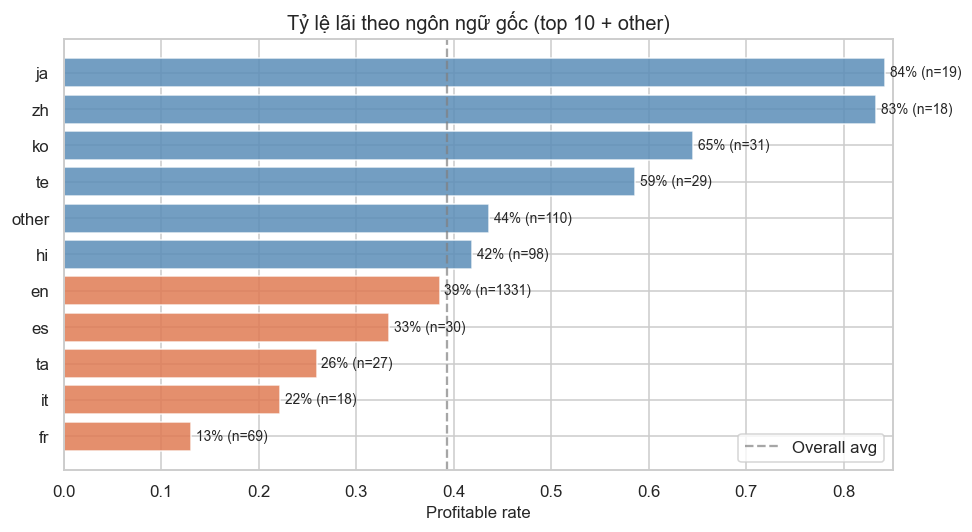

In [105]:
top_langs_train = df['original_language'].value_counts().head(N_LANG).index.tolist()
df['lang_grouped'] = df['original_language'].where(
    df['original_language'].isin(top_langs_train), 'other'
)

lang_stats = df.groupby('lang_grouped')['profitable'].agg(['mean','count'])
lang_stats = lang_stats.sort_values('mean', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors = [C1 if r >= df['profitable'].mean() else C0 for r in lang_stats['mean']]
bars   = ax.barh(lang_stats.index, lang_stats['mean'],
                 color=colors, alpha=0.85, edgecolor='white')
ax.axvline(df['profitable'].mean(), ls='--', color='gray', alpha=0.7, label='Overall avg')
for bar, (idx, row) in zip(bars, lang_stats.iterrows()):
    ax.text(row['mean'] + 0.005, bar.get_y() + bar.get_height()/2,
            f"{row['mean']*100:.0f}% (n={int(row['count'])})",
            va='center', fontsize=9)
ax.set_title(f'Tỷ lệ lãi theo ngôn ngữ gốc (top {N_LANG} + other)')
ax.set_xlabel('Profitable rate')
ax.set_xlim(0, 0.85)
ax.legend()
plt.tight_layout()
plt.show()

Số lượng phim tiếng Anh áp đảo hoàn toàn. Tỷ lệ lãi của nhóm này là 39%, nhiều khả năng đã kéo luôn mức trung bình tổng thể (~39%) về phía nó. ja, zh tuy có tỷ lệ lãi rất cao nhưng số lượng mẫu ít, nhiều khả năng chỉ có những phim rất xuất sắc mới được ghi nhận, không đủ đại diện.

**origin_country vs profitable**

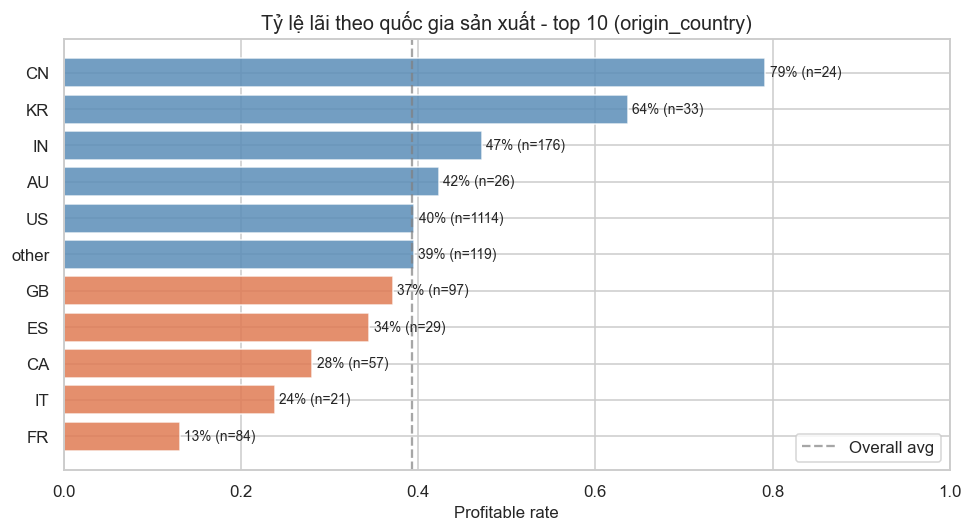

In [106]:
top_countries_train = df['origin_country'].explode().value_counts().head(N_COUNTRY).index.tolist()
df['country_grouped'] = df['origin_country'].apply(
    lambda x: next((c for c in (x if isinstance(x, list) else []) if c in top_countries_train), 'other')
)

country_stats = df.groupby('country_grouped')['profitable'].agg(['mean','count'])
country_stats = country_stats.sort_values('mean', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors = [C1 if r >= df['profitable'].mean() else C0 for r in country_stats['mean']]
bars   = ax.barh(country_stats.index, country_stats['mean'],
                 color=colors, alpha=0.85, edgecolor='white')
ax.axvline(df['profitable'].mean(), ls='--', color='gray', alpha=0.7, label='Overall avg')
for bar, (idx, row) in zip(bars, country_stats.iterrows()):
    ax.text(row['mean'] + 0.005, bar.get_y() + bar.get_height()/2,
            f"{row['mean']*100:.0f}% (n={int(row['count'])})",
            va='center', fontsize=9)
ax.set_title(f'Tỷ lệ lãi theo quốc gia sản xuất - top {N_COUNTRY} (origin_country)')
ax.set_xlabel('Profitable rate')
ax.set_xlim(0, 1.0)
ax.legend()
plt.tight_layout()
plt.show()

Tương tự language, bị US ảnh hưởng mạnh.

**n_pc (số production companies của mỗi phim - count) vs profitable**

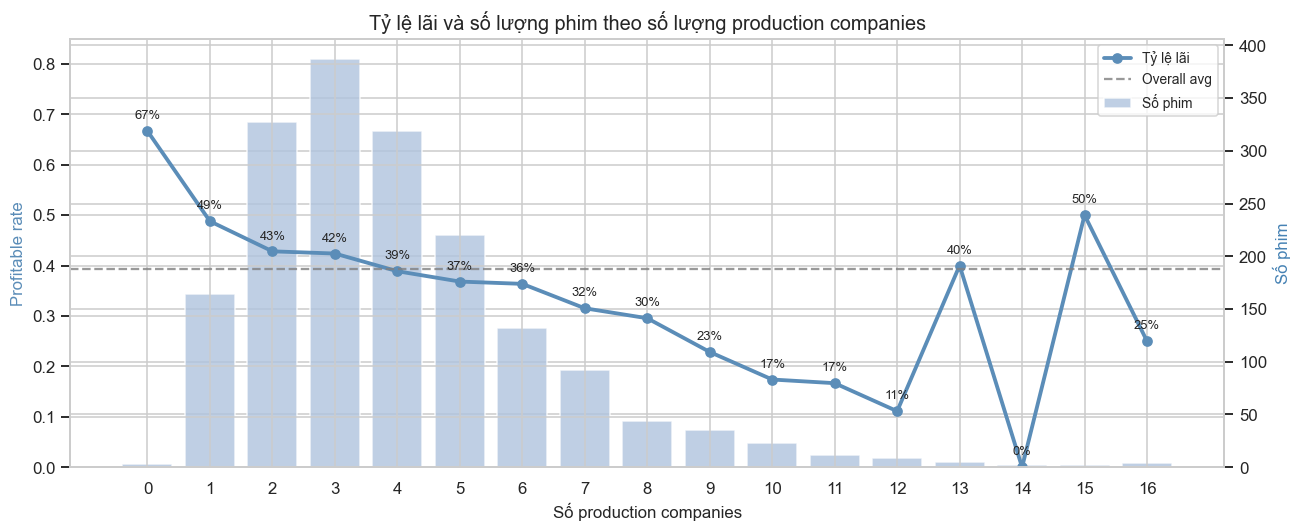

In [107]:
pc_rate = df.groupby('n_pc')['profitable'].agg(['mean','count'])

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()
ax1.set_zorder(ax2.get_zorder() + 1)
ax1.patch.set_visible(False)
ax2.bar(pc_rate.index, pc_rate['count'],
        color='lightsteelblue', alpha=0.8, label='Số phim')
ax1.plot(pc_rate.index, pc_rate['mean'],
         marker='o', color=C1, lw=2.5, label='Tỷ lệ lãi')
ax1.axhline(df['profitable'].mean(), ls='--', color='gray', alpha=0.8, label='Overall avg')

for idx, row in pc_rate.iterrows():
    ax1.annotate(f"{row['mean']*100:.0f}%",
                 (idx, row['mean']),
                 textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8.5)

ax1.set_xticks(pc_rate.index)
ax1.set_xlabel('Số production companies')
ax1.set_ylabel('Profitable rate', color=C1)
ax2.set_ylabel('Số phim', color='steelblue')
ax1.set_ylim(0, 0.85)
ax1.set_title('Tỷ lệ lãi và số lượng phim theo số lượng production companies')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

Khi số lượng nhà sản xuất tăng từ 1 lên 12, tỷ lệ lãi giảm liên tục và rõ rệt từ 49% xuống chỉ còn 11%. Nhóm phim có từ 1 đến 3 nhà sản xuất chiếm số lượng áp đảo và đều giữ tỷ lệ lãi khá tốt. Từ 13 NSX chủ yếu là nhiễu, lượng mẫu quá ít.

**n_keywords (count) vs profitable**

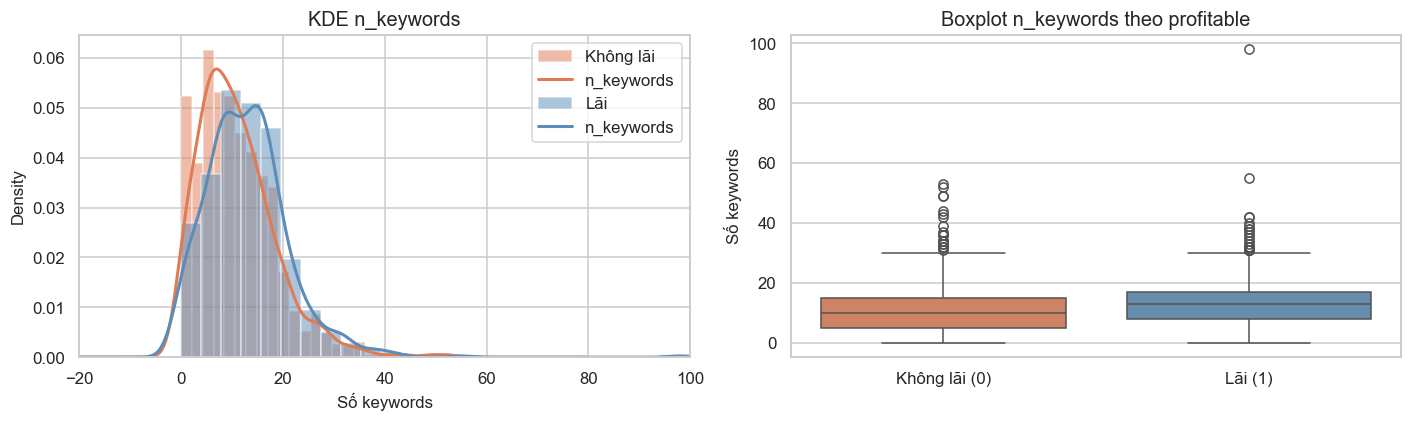

Median n_keywords - Không lãi: 10 | Lãi: 13


In [108]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

kw_0 = df[df['profitable']==0]['n_keywords']
kw_1 = df[df['profitable']==1]['n_keywords']
for label, data, color in [('Không lãi', kw_0, C0), ('Lãi', kw_1, C1)]:
    axes[0].hist(data, bins=25, alpha=0.5, color=color, density=True, label=label)
    data.plot.kde(ax=axes[0], color=color, lw=2)
axes[0].set_xlim(-20, 100) 
axes[0].set_title(f'KDE n_keywords')
axes[0].set_xlabel('Số keywords')
axes[0].legend()

kw_df = df[['profitable','n_keywords']].copy()
sns.boxplot(data=kw_df, x='profitable', y='n_keywords', ax=axes[1],
            palette={'0': C0, '1': C1})
axes[1].set_title('Boxplot n_keywords theo profitable')
axes[1].set_xticklabels(['Không lãi (0)', 'Lãi (1)'])
axes[1].set_xlabel('')
axes[1].set_ylabel('Số keywords')

plt.tight_layout()
plt.show()
print(f"Median n_keywords - Không lãi: {kw_0.median():.0f} | Lãi: {kw_1.median():.0f}")

Cả hai nhóm đều có dạng phân phối lệch phải. Phân phối n_keywords của nhóm phim Lãi (1) dịch chuyển về phía bên phải so với nhóm Không lãi (0). Trung vị của nhóm có lãi cao hơn 3 keyword. Phim có lãi thường có xu hướng sở hữu nhiều từ khóa chi tiết hơn. 

**Spearman correlation matrix tất cả numerical features**

Dùng Spearman vì phân phối các biến lệch (budget, n_keywords), và profitable là biến nhị phân.

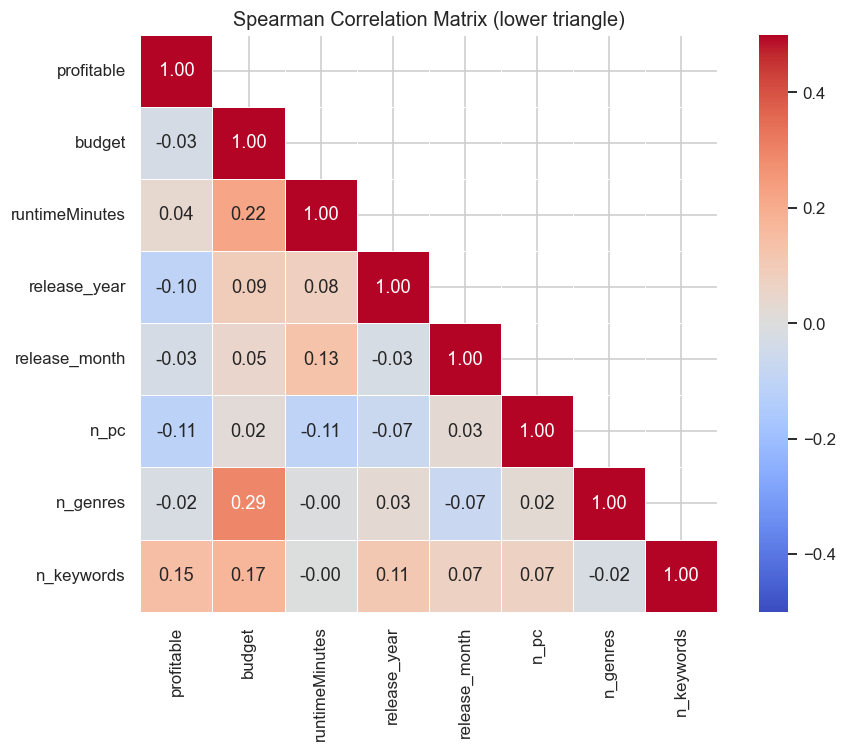

Correlation với profitable (Spearman, sắp xếp theo abs):
n_keywords        0.146
n_pc             -0.113
release_year     -0.103
runtimeMinutes    0.037
release_month    -0.030
budget           -0.028
n_genres         -0.022


In [109]:
num_features = ['profitable', 'budget', 'runtimeMinutes',
                'release_year', 'release_month', 'n_pc', 'n_genres', 'n_keywords']

corr_matrix = df[num_features].corr(method='spearman')

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-0.5, vmax=0.5, ax=ax, mask=mask,
            linewidths=0.5, linecolor='white', square=True)
ax.set_title('Spearman Correlation Matrix (lower triangle)')
plt.tight_layout()
plt.show()

print("Correlation với profitable (Spearman, sắp xếp theo abs):")
corr_target = corr_matrix['profitable'].drop('profitable')
print(corr_target.sort_values(key=abs, ascending=False).round(3).to_string())

Hệ số tương quan của tất cả các biến số với profitable đều nằm ở mức thấp đến trung bình yếu (< 0.15). Điều này chứng tỏ khả năng sinh lời của một bộ phim là một bài toán rất phức tạp, không phụ thuộc tuyến tính vào bất kỳ một yếu tố đơn lẻ nào. 

##### Kết luận
- Biến mục tiêu (profitable): Khả năng sinh lời của một bộ phim là một hàm số phức tạp, không phụ thuộc tuyến tính vào bất kỳ yếu tố đơn lẻ nào.
- Nhóm ưu tiên sử dụng các mô hình học máy tree-based. Các thuật toán này có khả năng tự động phân tách dữ liệu dựa trên các tương tác chéo đa biến hiệu quả mà ít bị ảnh hưởng bởi phân phối lệch hay các điểm outlier.
- Kết quả mô hình cần được diễn giải trong bối cảnh nghiêng về phim có ngân sách trung bình-lớn, phát hành rộng rãi, chủ yếu Anh ngữ do selection bias.